# load in libraries

In [1]:
#### libraries ####
import os
import mne
import numpy as np
import matplotlib.pyplot as plt
import pickle
import pandas as pd


from scipy import signal
from scipy.io import wavfile

# from pybv import write_brainvision
from pyprep.prep_pipeline import PrepPipeline
from mne_icalabel import label_components

# working directory
work_dir = '/Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/'

# trigger latency correction

In [107]:
# directory
input_dir = work_dir + 'eeg_raw/curry/'
output_dir = work_dir + 'eeg_preprocessed/1_trigger_latency_corrected/'


# create a dictionary for blocks and block markers
block_dict = {
    'dorsal_highStan_lowDevi': 1000, # standard: dorsal_high; deviant: dorsal_low
    'dorsal_lowStan_highDevi': 2000, # standard: dorsal_low; deviant: dorsal_high
    'glottal_highStan_lowDevi': 3000, # standard: glottal_high; deviant: glottal_low
    'glottal_lowStan_highDevi': 4000, # standard: glottal_low; deviant: glottal_high
}


# participants to exclude
exclude_ppts = [
]

# trigger searching window (actual trigger time based on audio - trigger time in the data)
t_left = -0.01
t_right = 0.2

#######################################################
#### create a dictionary for trigger codes and descriptions ####
df = pd.read_csv('mapping_vot.txt', delimiter='\t')
VOT_mapping = dict(zip(df['code'], df['description']))

df = pd.read_csv('mapping_f0.txt', delimiter='\t')
F0_mapping = dict(zip(df['code'], df['description']))
#######################################################



##### trigger lag fix #####

# initialize a dictionary to save bad stims
# all_bad_stim_dict = {}

# read in eeg data files
all_files = os.listdir(input_dir)

#### for each file, create an all_block dictionary to store each block and the indices of trials of that block  ####
for file in all_files:
    if file.endswith('.cdt') and (file.split('.')[0] not in exclude_ppts) and (file.split('.')[0]+ '_corr.fif' not in os.listdir(output_dir)):

        # read in vhdr files
        raw = mne.io.read_raw_curry(input_dir + file, preload = True)
        
        # extract the info of experiment version
        exp_ver = file.split('.')[0].split('_')[2]

        # extract sampling rate
        eeg_sfreq = raw.info['sfreq']
        
        ##########################################################################################
        #### create a trigger dictionary for each stim's standard version and deviant version ####
        
        # intialize a dictionary for triggers
        trigger_dict = {}
        
        # read in trigger_codes file, and create a standard trigger code and a deviant triggre code for each stimulus
        with open(work_dir + 'experiment programs/'+exp_ver+'_eeg/trigger_codes.txt','r') as tf:
            for line in tf:
                # read in the current line
                line = line.replace('\n','')
                # separate fileNames and triggerMarker
                label, marker = line.split('\t')
                # convert trigger markers to integer
                marker = int(marker)
                # create label for stims used as standards
                trigger_dict[marker] = label + '-s'
                # add 100 for deviant marker
                marker_deviant = marker + 100
                # create label for stims used as deviants
                trigger_dict[marker_deviant] = label + '-d'
        
        ################################
        #### downsample audio files ####
        ################################
        
        # initialize dictionaries
        audio = {}
        lengths = {}
        
        # del trigger_dict[99999]
        # for each trigger code and label in the trigger dictionary
        for marker,label in trigger_dict.items():
            # extract file name, up to the -2 character of the label
            file_name = label[:-2]
            # if not already in audio dictionary, get the info of the audio file
            if file_name not in audio:
                # get sample rate and data of the audio file
                sampleRate, data = wavfile.read(work_dir + 'experiment programs/'+exp_ver+'_eeg/stimuli/{}.wav'.format(file_name))
                # calculate sound file length
                lengths[file_name] = len(data)/sampleRate
                # reduce the sampling rate of the audio file by the factor of int(sampleRate/eeg_freq)
                data_downsampled = signal.decimate(data, int(sampleRate/eeg_freq), ftype='fir')
                # add info the audio dictionary
                audio[file_name] = data_downsampled
        
        ##########################################
        #### trigger value correction for each file ####
        ##########################################
        
        
        #### making events ####
        # for each stimulus, mark the block info
        events_from_annot, event_dict = mne.events_from_annotations(raw, verbose='WARNING')
        
        # invert the event_dict dictionary, as the key (NOT the value) matches the trigger code in the trigger code list
        inverted_event_dict = {v: k for k, v in event_dict.items()}        
        
        # # remove the New Segment marker (which has a trigger value of 99999) and pause marker (222) and continue marker (223)
        # events_from_annot = events_from_annot[events_from_annot[:, 2] < 200]
        
        # initialize the train for each standards+deviant sequence
        train = np.array([]).astype(int)
        
        all_block = {}
        isStandard = True # whether the standard in a train has been noted
        
        # loop over each trigger
        for i in range(events_from_annot.shape[0]):
        
            # get trigger value
            trigger_value = int( inverted_event_dict[events_from_annot[i,2]] )

            # replace the trigger value in events_from_annot by the event_dict key
            events_from_annot[i,2] = trigger_value
        
            # add the current token to the train if it's smaller than 150 (the largest stim trigger value is 136)
            if trigger_value<150:
                train = np.append(train,i)
        
                # if the trigger value is smaller than 100 (standard) and the standard toggle is true
                if (trigger_value<100) & isStandard:
                    # split the file name
                    trigger_splitted = trigger_dict[trigger_value].split('_')
                    # get the standard category name
                    block = trigger_splitted[1] + '_' + trigger_splitted[2] + 'Stan'
                    # toggle standard
                    isStandard = False
            
                # if the trigger value is over 100 (deviant)
                elif trigger_value>100:
                    # split the file name
                    trigger_splitted = trigger_dict[trigger_value].split('_')
                    # append the deviant stim category 
                    block = block + '_' + trigger_splitted[2] + 'Devi'
            
                    # if the block is not present in all block
                    if block not in all_block:
                        # add the new block and the token idx
                        all_block[block] = train[2:] # [2:] to exclude the first 2 standards
                    else:
                        # add the token idx to the existing block
                        all_block[block] = np.concatenate([all_block[block],train[2:]],axis = None)
            
                    # reset train
                    train = np.array([]).astype(int)
            
                    # toggle standard
                    isStandard = True
        
        # loop over each block and its trigger index
        for k,v in all_block.items():
            # recode the trigger value to reflect block and stim category
            events_from_annot[tuple(v),2] += block_dict[k]
        
        # generate new events
        events_from_annot = events_from_annot[events_from_annot[:,2]>1000]
        ##################################################################

        #### to delete ######
        # # convert individual event marker to conditions
        # events_from_annot[:,2] = events_from_annot[:,2] - events_from_annot[:,2]%100
        #### to delete ######
        
        # ########################################################
        # #### calculate cross correction to detect the delay ####
        
        # # initialize delay list
        # delays = np.array([])
        # # initialize bad stim list
        # bad_stim = []
        # corr_results = []
        
        # # loop over each event
        # for i in range(events_from_annot.shape[0]):
        
        #     # get current event info [time, duration, annotation]
        #     event = events_from_annot[i]
        #     # get the onset latency (s) of the event
        #     time = event[0]/raw.info['sfreq']
        #     # get the file name of the event
        #     name = trigger_dict[event[2]%100].split('-')[0]
        #     # get the data from the sound channel
        #     audio_eeg = raw.get_data(
        #         picks = ['StimTrak'],
        #         tmin = time + t_left,
        #         tmax = time + lengths[name] + t_right,
        #     )[0]
        
        #     # Z-score normalization (subtract mean, divide by std)
        #     audio_eeg = (audio_eeg - np.mean(audio_eeg)) / np.std(audio_eeg)
        #     audio[name] = (audio[name] - np.mean(audio[name])) / np.std(audio[name])
            
        #     # cross-correlation
        #     corr = signal.correlate(audio_eeg, audio[name], mode='full')
        #     # Normalize cross-correlation
        #     # corr = corr / (np.linalg.norm(audio_eeg) * np.linalg.norm(audio[name]))
        #     # Find peak correlation value
        #     max_corr = np.max(corr)            
            
        #     # if the maximum correction (sum of products) is less than a threshold (empirical threshold, experiment-specific)
        #     if max_corr < 200:
        #         # mark the stim bad
        #         bad_stim.append(i)
        
        #     # append the maximum correlation
        #     corr_results.append(max_corr)
        
            
        #     # the lags for cross-correlation
        #     lags = signal.correlation_lags(
        #         audio_eeg.size,
        #         audio[name].size,
        #         mode="full")
        #     # get the lag of the maximum cross-correlation
        #     lag = lags[np.argmax(corr)] + t_left*raw.info['sfreq']
            
        #     # save the lag for non-starting events
        #     delays = np.append(delays,lag)
        
        # #############
        # # plot the wave from the stim track and the eeg channel of the token with the minimum corr #
        # #############
        
        # min_corr = np.argmin(corr_results)
        # # get current event info [time, duration, annotation]
        # event = events_from_annot[min_corr]
        # # get the onset latency (s) of the event
        # time = event[0]/raw.info['sfreq']
        # # get the file name of the event
        # name = trigger_dict[event[2]%100].split('-')[0]
        # # get the data from the sound channel
        # audio_eeg = raw.get_data(
        #     picks = ['StimTrak'],
        #     tmin = time + t_left,
        #     tmax = time + lengths[name] + t_right,
        # )[0]
        
        # # Z-score normalization (subtract mean, divide by std)
        # audio_eeg = (audio_eeg - np.mean(audio_eeg)) / np.std(audio_eeg)
        # audio[name] = (audio[name] - np.mean(audio[name])) / np.std(audio[name])
        
        # fig, ax = plt.subplots()
        # ax.plot(audio_eeg, label = 'StimTrak')
        # ax.plot(audio[name], label = 'wave')
        # ax.set_title(file)
        # ax.legend()
        # fig.savefig(output_dir + file.split('.')[0] + "_minCor.png", dpi=300, bbox_inches='tight')
        # ##########################
                
        # # if there is a bad stim
        # if len(bad_stim)>0:
        #     # wave the number of bad stims to a file
        #     with open(output_dir + 'bad_stim.txt', 'a+') as f:
        #         _ =f.write(file + '\t' + str(len(bad_stim)) + ' bad stims' + '\n')
        
        
        # # remove items associated with bad stims from the event list
        # events_from_annot = np.delete(events_from_annot, bad_stim, 0)
        
        # # remove items associated with bad stims from the delay list
        # delays = np.delete(delays, bad_stim, 0)
        
        # # save single-trial delay file
        # np.savetxt(output_dir + file.replace('.vhdr', '_delays.txt'), delays, fmt='%i')
        
        
        # # correct for trigger delay
        
        # # add delay back to the onset latency of each event
        # events_from_annot[:,0] = events_from_annot[:,0] + delays
        ##### trigger delay correction end #####

        # convert individual event marker to conditions
        # events_from_annot[:,2] = events_from_annot[:,2] - events_from_annot[:,2]%100
        
        # create annotations
        annot_from_events = mne.annotations_from_events(
            events = events_from_annot,
            event_desc = eval(exp_ver + '_mapping'),
            sfreq = eeg_sfreq
        )
        
        # set annotations
        raw.set_annotations(annot_from_events)
        
        # drop the audio channel in data
        raw.drop_channels(['Trigger'])
        
        # save as a file-into-file data
        raw.save(output_dir + file.split('.')[0]+ '_corr.fif')

Leaving device<->head transform as None (no landmarks found)
Reading 0 ... 2307399  =      0.000 ...  4614.798 secs...
Event file found. Extracting Annotations from /Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_raw/curry/KCUE2025_0004_F0.cdt.ceo...
Writing /Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/1_trigger_latency_corrected/KCUE2025_0004_F0_corr.fif


/var/folders/j8/8nyf6njj5nzfjcv6s23y3nn40000gn/T/ipykernel_4096/1014744032.py:305: RuntimeWarning: This filename (/Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/1_trigger_latency_corrected/KCUE2025_0004_F0_corr.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save(output_dir + file.split('.')[0]+ '_corr.fif')


Closing /Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/1_trigger_latency_corrected/KCUE2025_0004_F0_corr.fif
[done]
Leaving device<->head transform as None (no landmarks found)
Reading 0 ... 2318499  =      0.000 ...  4636.998 secs...
Event file found. Extracting Annotations from /Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_raw/curry/KCUE2025_0021_VOT.cdt.ceo...
Writing /Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/1_trigger_latency_corrected/KCUE2025_0021_VOT_corr.fif


/var/folders/j8/8nyf6njj5nzfjcv6s23y3nn40000gn/T/ipykernel_4096/1014744032.py:305: RuntimeWarning: This filename (/Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/1_trigger_latency_corrected/KCUE2025_0021_VOT_corr.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save(output_dir + file.split('.')[0]+ '_corr.fif')


Closing /Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/1_trigger_latency_corrected/KCUE2025_0021_VOT_corr.fif
[done]
Leaving device<->head transform as None (no landmarks found)
Reading 0 ... 2306649  =      0.000 ...  4613.298 secs...
Event file found. Extracting Annotations from /Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_raw/curry/KCUE2025_0007_VOT.cdt.ceo...
Writing /Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/1_trigger_latency_corrected/KCUE2025_0007_VOT_corr.fif


/var/folders/j8/8nyf6njj5nzfjcv6s23y3nn40000gn/T/ipykernel_4096/1014744032.py:305: RuntimeWarning: This filename (/Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/1_trigger_latency_corrected/KCUE2025_0007_VOT_corr.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save(output_dir + file.split('.')[0]+ '_corr.fif')


Closing /Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/1_trigger_latency_corrected/KCUE2025_0007_VOT_corr.fif
[done]
Leaving device<->head transform as None (no landmarks found)
Reading 0 ... 2423549  =      0.000 ...  4847.098 secs...
Event file found. Extracting Annotations from /Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_raw/curry/KCUE2025_0017_VOT.cdt.ceo...
Writing /Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/1_trigger_latency_corrected/KCUE2025_0017_VOT_corr.fif


/var/folders/j8/8nyf6njj5nzfjcv6s23y3nn40000gn/T/ipykernel_4096/1014744032.py:305: RuntimeWarning: This filename (/Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/1_trigger_latency_corrected/KCUE2025_0017_VOT_corr.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save(output_dir + file.split('.')[0]+ '_corr.fif')


Closing /Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/1_trigger_latency_corrected/KCUE2025_0017_VOT_corr.fif
[done]


## spectrum

Opening raw data file /Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/1_trigger_latency_corrected/KCUE2025_0001_F0_corr.fif...
    Range : 0 ... 2365599 =      0.000 ...  4731.198 secs
Ready.
Reading 0 ... 2365599  =      0.000 ...  4731.198 secs...


/var/folders/j8/8nyf6njj5nzfjcv6s23y3nn40000gn/T/ipykernel_40620/3459488257.py:27: RuntimeWarning: This filename (/Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/1_trigger_latency_corrected/KCUE2025_0001_F0_corr.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(input_dir + file, preload = True)


Effective window size : 4.096 (s)


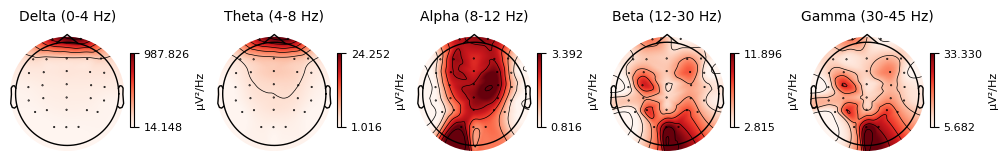

In [23]:
## parameters
# frequency of the eeg recording for audio downsampling
# eeg_freq = 500

# directory
input_dir = work_dir + 'eeg_preprocessed/1_trigger_latency_corrected/'

# file name
file = 'KCUE2025_0001_F0_corr.fif'

# montage
montage = mne.channels.make_standard_montage("standard_1020")

# for renaming channels to match the mne montage file
chan_mapping = {
    'CPZ': 'CPz',
    'OZ': 'Oz',
    'PZ': 'Pz',
    'CZ': 'Cz',
    'FCZ': 'FCz',
    'FZ': 'Fz',
    'FP2': 'Fp2',
    'FP1': 'Fp1',
}

# read in file
raw = mne.io.read_raw_fif(input_dir + file, preload = True)

# rename channels
mne.rename_channels(raw.info, mapping=chan_mapping)

raw.drop_channels(['M1', 'M2'])

raw.set_montage(montage)


# # if needed, plot a spectrum for each channel
# for chan in raw.info['ch_names']:
#     print('=====================')
#     print(chan)
#     raw.compute_psd(picks = chan, fmax=100).plot()
#     plt.show()

raw.compute_psd().plot_topomap()
plt.show()

# Bad channel correction
- filtering
- resampling
- remove line noise
- bad channel detection & repairing
- add back reference channels

In [175]:
#### parameters ####

# set directory
input_dir = work_dir + 'eeg_preprocessed/1_trigger_latency_corrected/'
output_dir = work_dir + 'eeg_preprocessed/2_bad_channel_corrected/'

# filter cutoff frequencies
f_low = 1
f_high = 100

# sampling frequency
f_res = 250

# line frequency
line_freq = 60

# preprocessing parameters
prep_params = {
    "ref_chs": 'eeg',
    "reref_chs": 'eeg', # average re-reference
    "line_freqs": np.arange(line_freq, f_res/2, line_freq),
}

# montage
montage = mne.channels.make_standard_montage("standard_1020")

# for renaming channels to match the mne montage file
chan_mapping = {
    'CPZ': 'CPz',
    'OZ': 'Oz',
    'PZ': 'Pz',
    'CZ': 'Cz',
    'FCZ': 'FCz',
    'FZ': 'Fz',
    'FP2': 'Fp2',
    'FP1': 'Fp1',
}

# interpolation method
# method=dict(eeg="spline")


#####################################################
#### filtering, resampling, bad channel detection/interpoloation, re-reference ####
#####################################################

# get all file namesin the folder
all_input = os.listdir(input_dir)
all_output = os.listdir(output_dir)


for file in all_input:
    if file.endswith("corr.fif") & (file.split('.')[0]+ '_prep.fif' not in all_output):
        
        # read in file
        raw = mne.io.read_raw_fif(input_dir + file, preload=True)

        # drop reference channels
        raw.drop_channels(['M1', 'M2'])

        # rename channels
        mne.rename_channels(raw.info, mapping=chan_mapping)

        # set channel type
        raw.set_channel_types({'Fp1':'eog', 'Fp2':'eog'})

        # filter
        raw.filter(l_freq = f_low, h_freq = f_high)
        
        #### cut off the beginning and ending part ####
        
        # get the onset of the first and the last event ####
        events_from_annot, event_dict = mne.events_from_annotations(raw, verbose='WARNING')

        # define the beginning time (in seconds)
        crop_start = events_from_annot[0][0]/raw.info['sfreq'] - 10

        # define the ending time (in seconds)
        crop_end = events_from_annot[-1][0]/raw.info['sfreq'] + 10

        # crop the data
        raw.crop(
            tmin=max(crop_start, raw.times[0]), 
            tmax=min(crop_end, raw.times[-1])
        )

        # resample
        raw.resample(sfreq = f_res)
        
        # read in channel location info
        raw.set_montage(montage)
        
        ####  Use PrePipeline to preprocess ####
        '''
        1. detect and interpolate bad channels
        2. remove line noise
        3. re-reference
        '''

        # apply pyprep
        prep = PrepPipeline(raw, prep_params, montage, random_state=42)
        prep.fit()
        
        # export a txt file for the interpolated channel info
        with open(output_dir + 'bad_channel.txt', 'a+') as f:
            _ =f.write(
                file + ':\n' +
                "- Bad channels original: {}".format(prep.noisy_channels_original["bad_all"]) + '\n' +
                "- Bad channels after robust average reference: {}".format(prep.interpolated_channels) + '\n' +
                "- Bad channels after interpolation: {}".format(prep.still_noisy_channels) + '\n'
            )

        # save the pyprep preprocessed data
        raw = prep.raw

        # spline interpolating remaining bad channels if any
        raw.interpolate_bads()

        # NOTE: add reference channels one by one to avoid the bug that overlaps reference channels if added simultaneously
        # add back the reference channel
        raw = mne.add_reference_channels(raw, ref_channels = ['M1'])
        # add the channel loc info (for the newly added reference channel)
        raw.set_montage(montage)
        # add back the reference channel
        raw = mne.add_reference_channels(raw, ref_channels = ['M2'])
        # add the channel loc info (for the newly added reference channel)
        raw.set_montage(montage)

        # save
        raw.save(output_dir + file.split('.')[0]+ '_prep.fif')

Opening raw data file /Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/1_trigger_latency_corrected/KCUE2025_0015_VOT_corr.fif...


/var/folders/j8/8nyf6njj5nzfjcv6s23y3nn40000gn/T/ipykernel_4096/759922554.py:56: RuntimeWarning: This filename (/Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/1_trigger_latency_corrected/KCUE2025_0015_VOT_corr.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(input_dir + file, preload=True)


    Range : 0 ... 2393449 =      0.000 ...  4786.898 secs
Ready.
Reading 0 ... 2393449  =      0.000 ...  4786.898 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 1651 samples (3.302 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


...


RANSAC done!
Setting channel interpolation method to {'eeg': 'spline'}.


/var/folders/j8/8nyf6njj5nzfjcv6s23y3nn40000gn/T/ipykernel_4096/759922554.py:117: RuntimeWarning: No bad channels to interpolate. Doing nothing...
  raw.interpolate_bads()
/var/folders/j8/8nyf6njj5nzfjcv6s23y3nn40000gn/T/ipykernel_4096/759922554.py:121: RuntimeWarning: Location for this channel is unknown or ambiguous; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
  raw = mne.add_reference_channels(raw, ref_channels = ['M1'])
/var/folders/j8/8nyf6njj5nzfjcv6s23y3nn40000gn/T/ipykernel_4096/759922554.py:123: RuntimeWarning: Not setting positions of 2 eog channels found in montage:
['Fp1', 'Fp2']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw.set_montage(montage)


Writing /Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/2_bad_channel_corrected/KCUE2025_0021_VOT_corr_prep.fif


/var/folders/j8/8nyf6njj5nzfjcv6s23y3nn40000gn/T/ipykernel_4096/759922554.py:125: RuntimeWarning: Location for this channel is unknown or ambiguous; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
  raw = mne.add_reference_channels(raw, ref_channels = ['M2'])
/var/folders/j8/8nyf6njj5nzfjcv6s23y3nn40000gn/T/ipykernel_4096/759922554.py:127: RuntimeWarning: Not setting positions of 2 eog channels found in montage:
['Fp1', 'Fp2']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw.set_montage(montage)
/var/folders/j8/8nyf6njj5nzfjcv6s23y3nn40000gn/T/ipykernel_4096/759922554.py:130: RuntimeWarning: This filename (/Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/2_bad_channel

Closing /Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/2_bad_channel_corrected/KCUE2025_0021_VOT_corr_prep.fif
[done]


## spectrum

Opening raw data file /Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/2_bad_channel_corrected/KCUE2025_0001_F0_corr_prep.fif...


/var/folders/j8/8nyf6njj5nzfjcv6s23y3nn40000gn/T/ipykernel_40620/882743006.py:12: RuntimeWarning: This filename (/Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/2_bad_channel_corrected/KCUE2025_0001_F0_corr_prep.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(input_dir + file, preload = True)


    Range : 17133 ... 1180934 =     68.532 ...  4723.736 secs
Ready.
Reading 0 ... 1163801  =      0.000 ...  4655.204 secs...
CPz
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


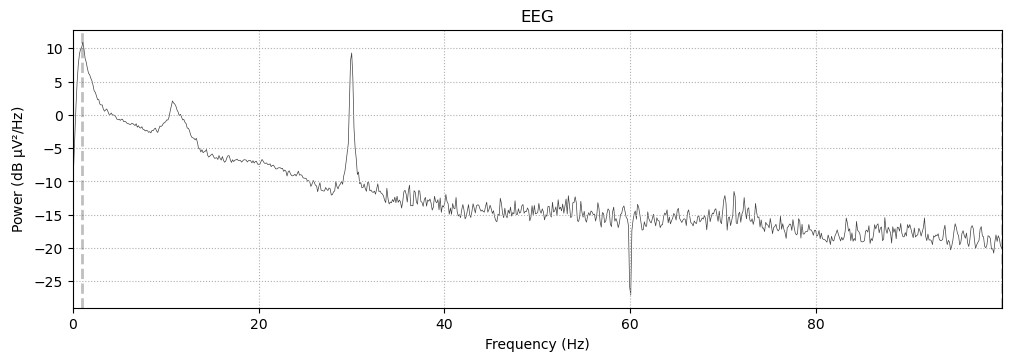

FC4
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


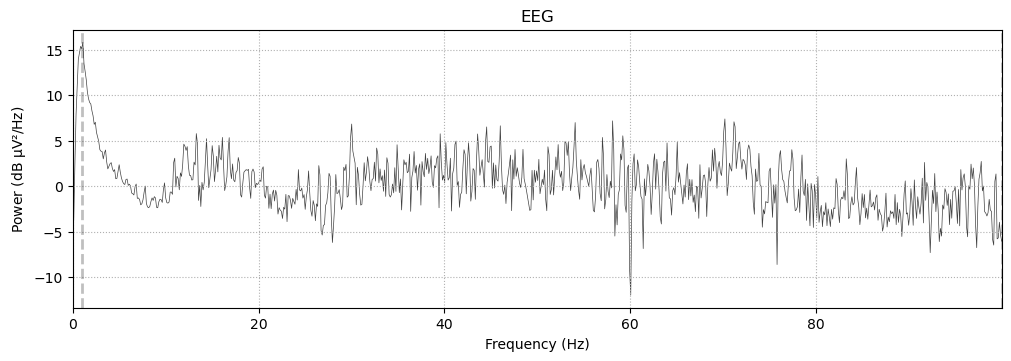

Oz
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


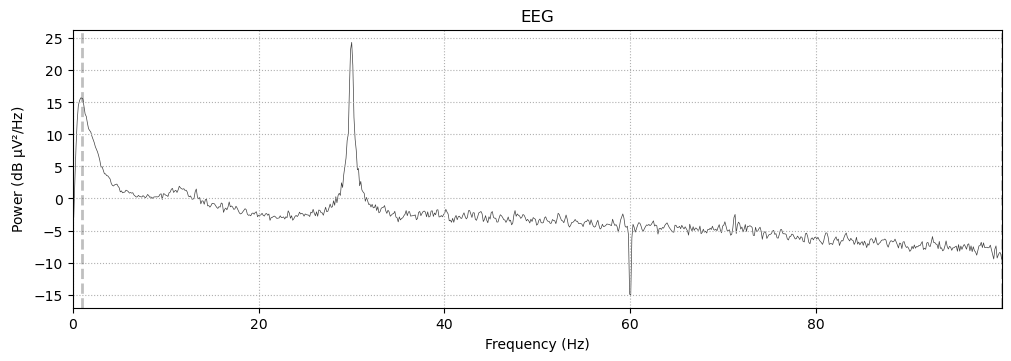

Pz
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


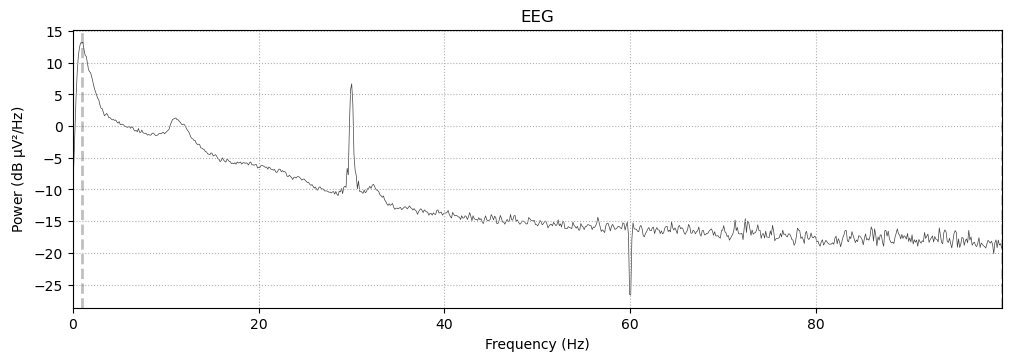

CP4
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


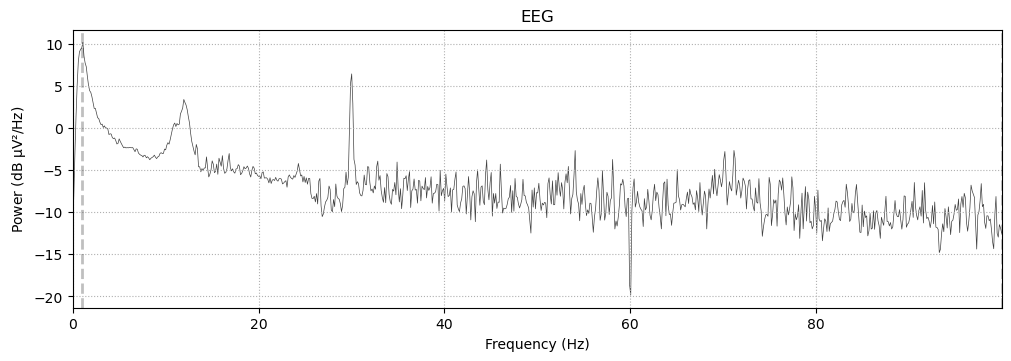

P8
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


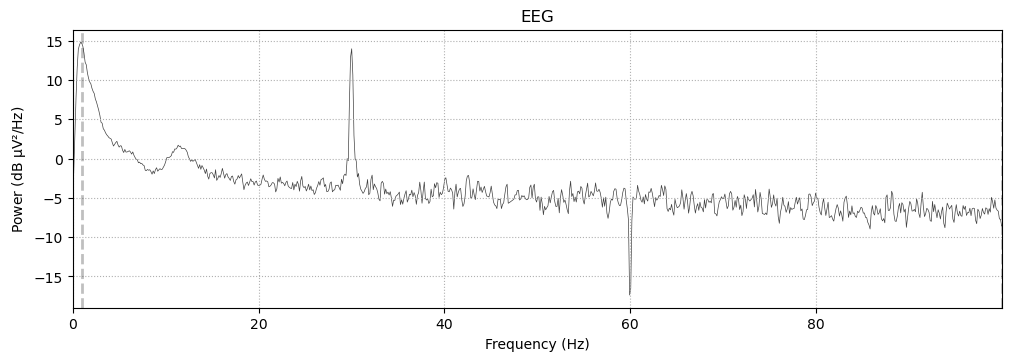

TP8
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


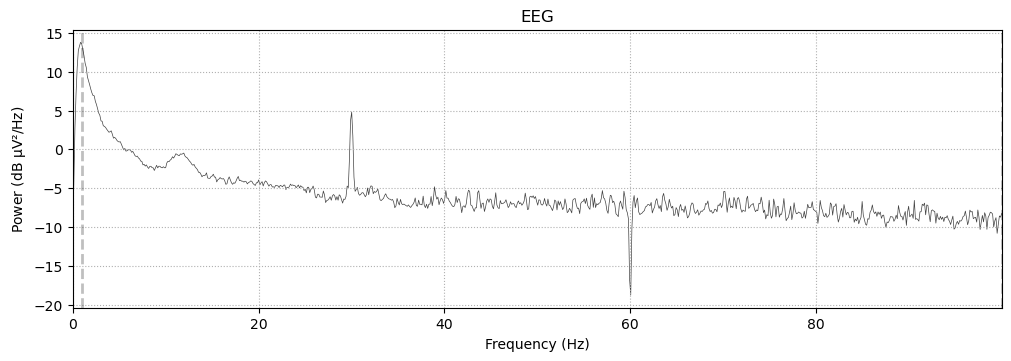

T8
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


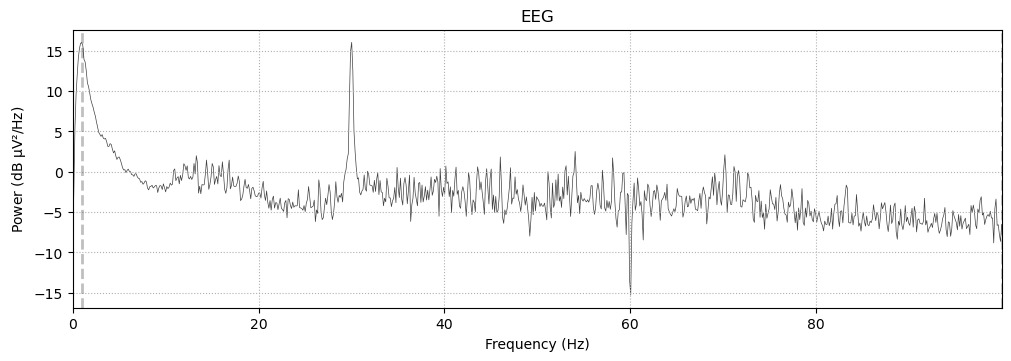

P7
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


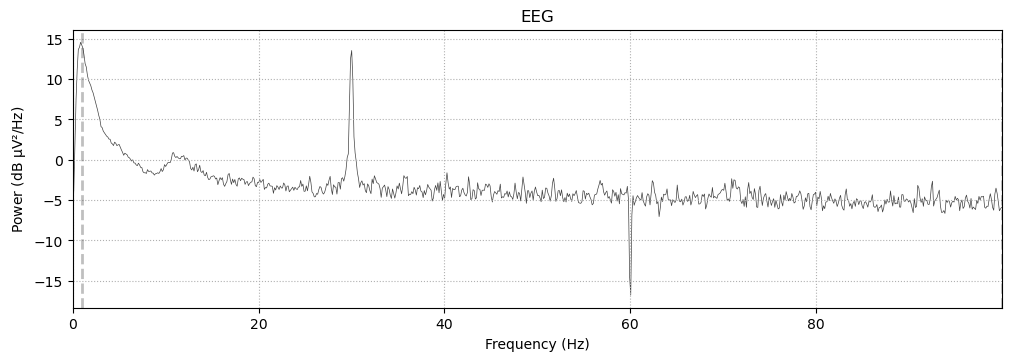

P3
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


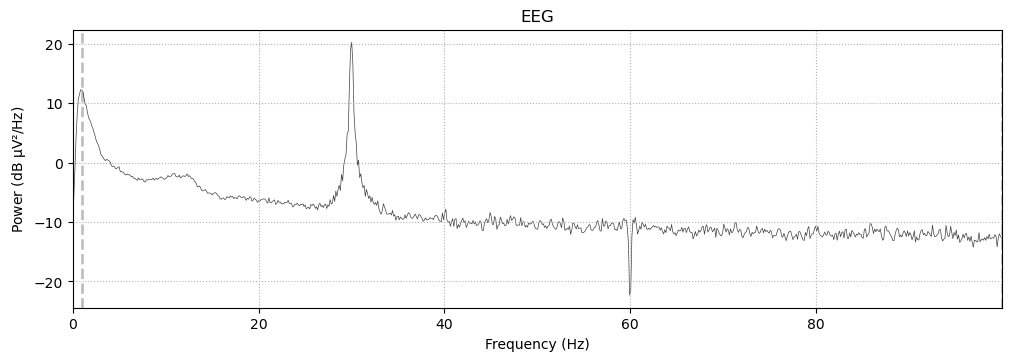

CP3
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


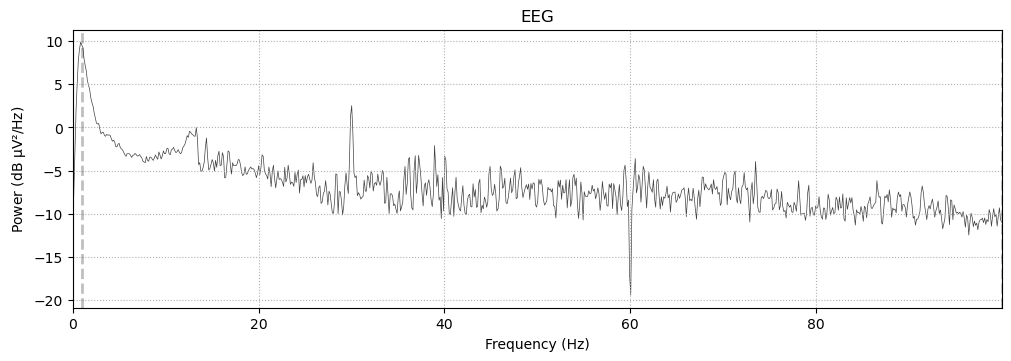

O2
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


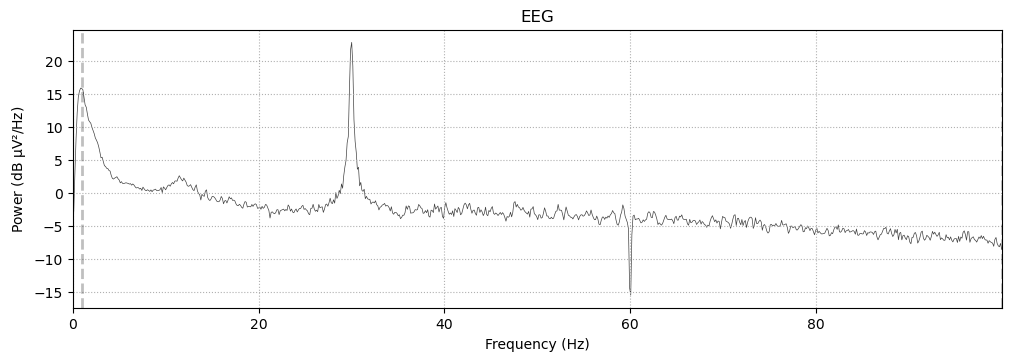

Cz
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


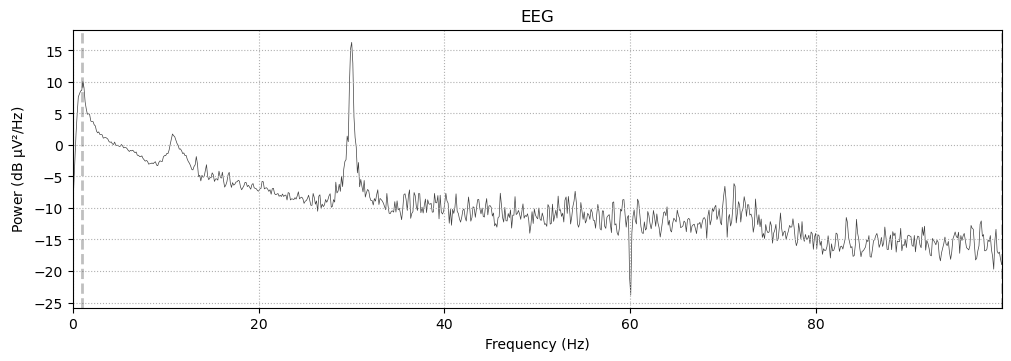

O1
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


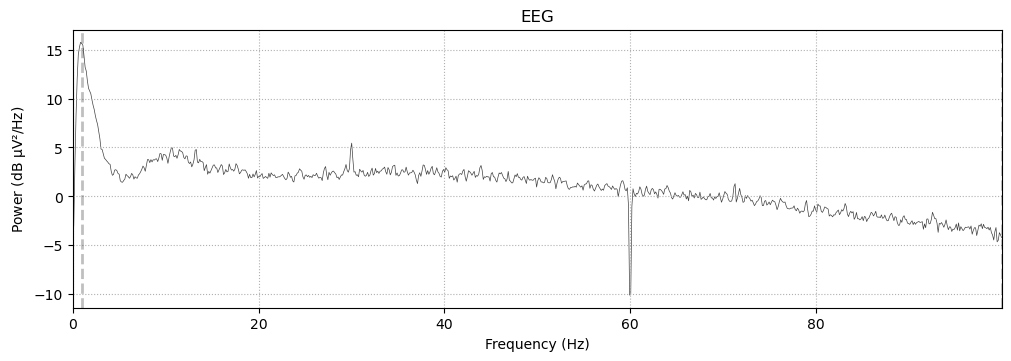

FT8
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


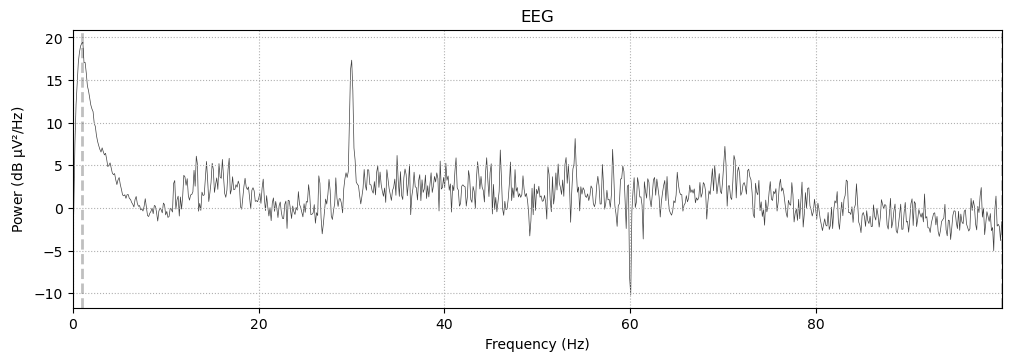

TP7
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


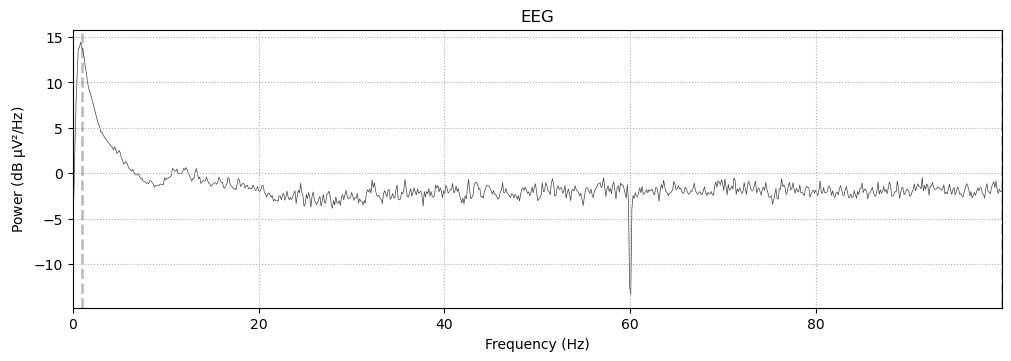

C3
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


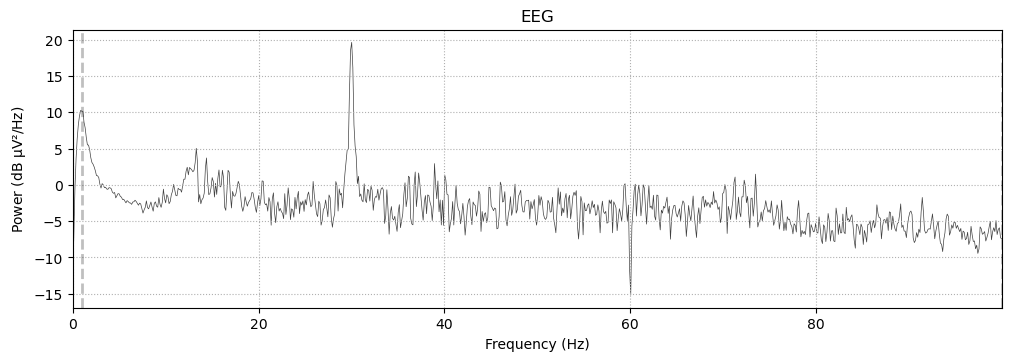

FCz
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


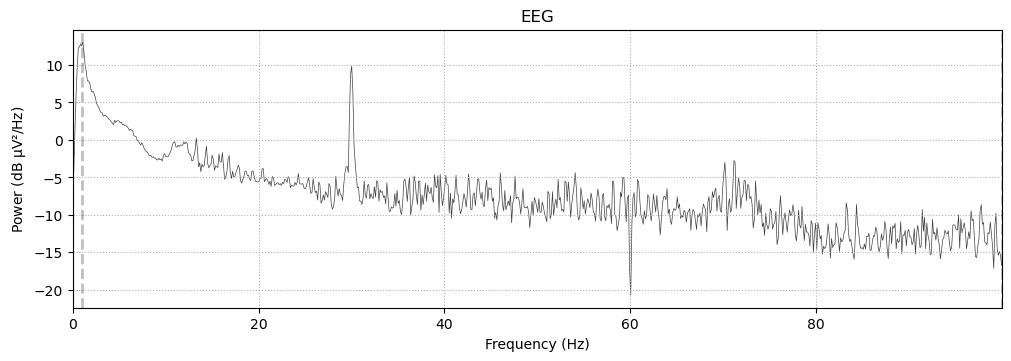

Fz
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


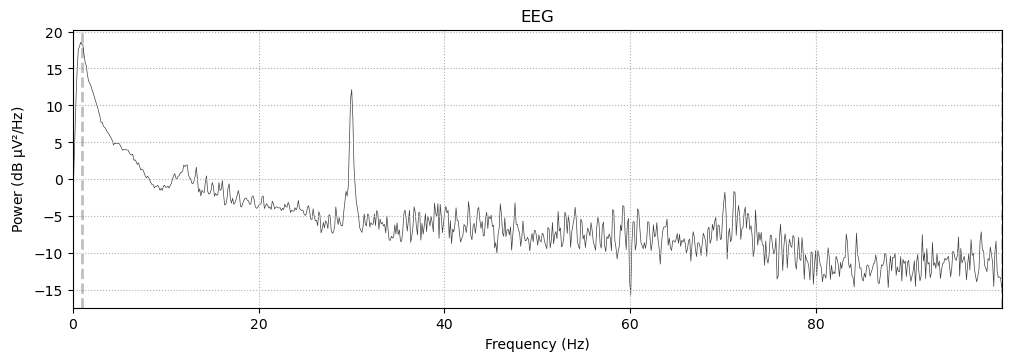

F4
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


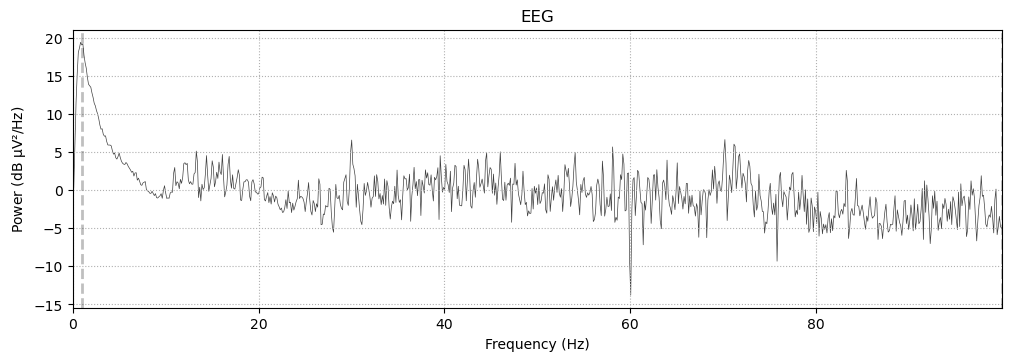

F8
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


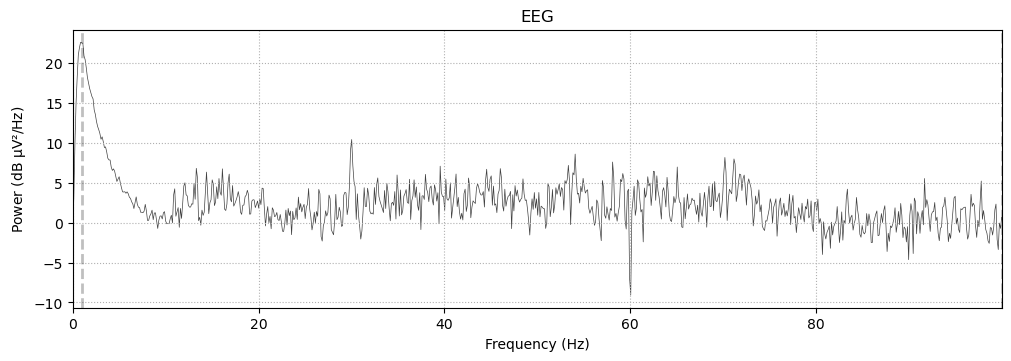

T7
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


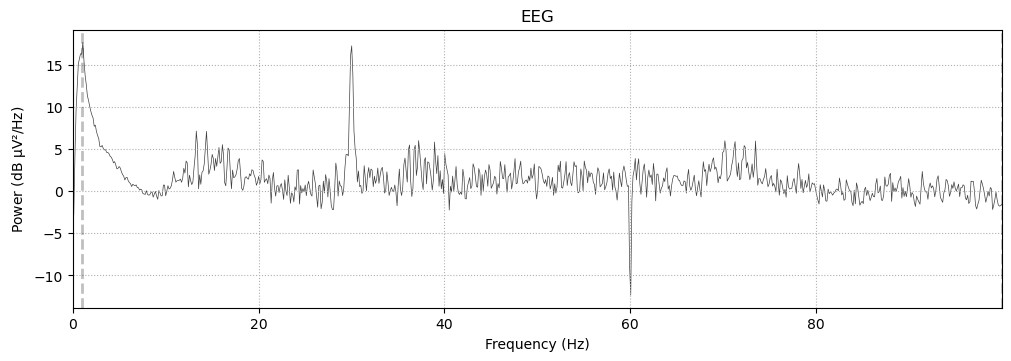

FT7
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


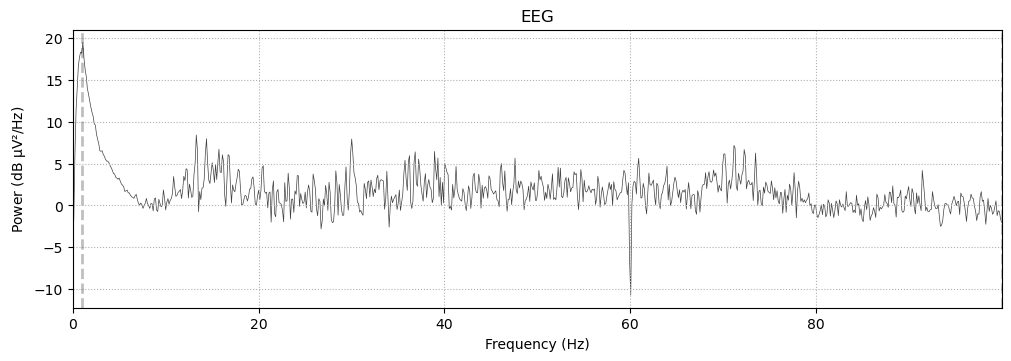

FC3
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


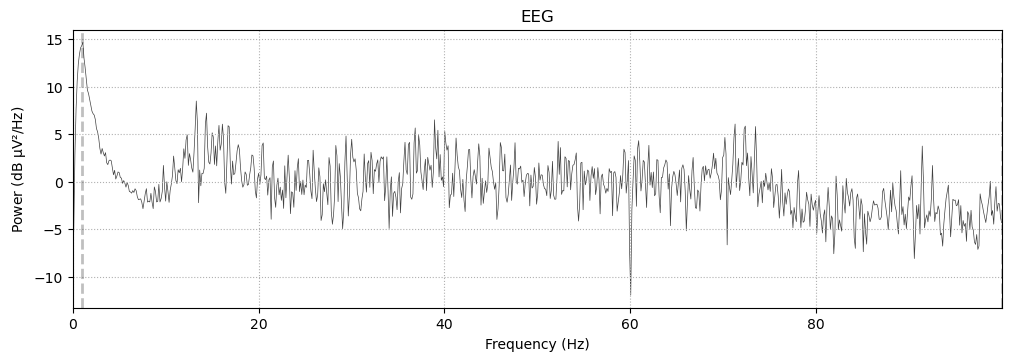

F3
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


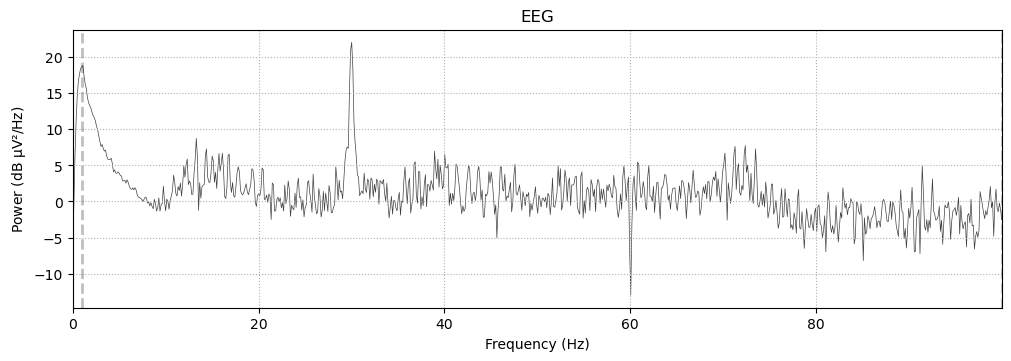

F7
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


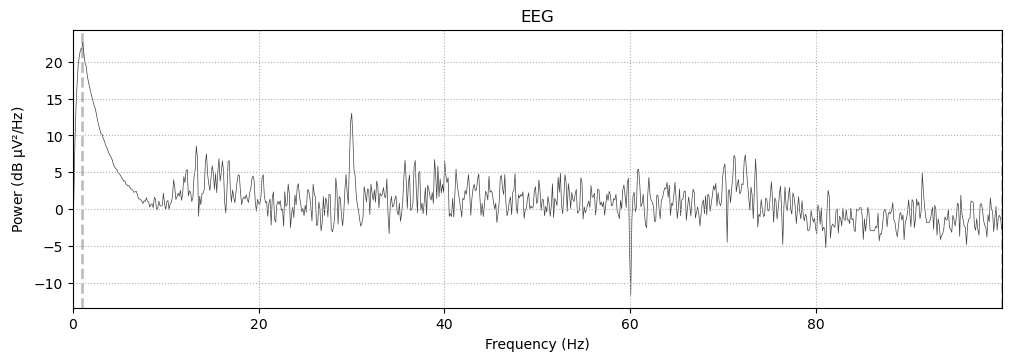

C4
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


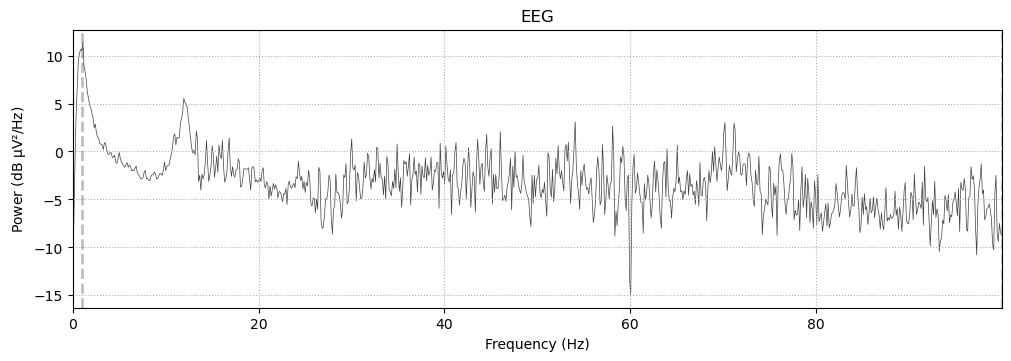

P4
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


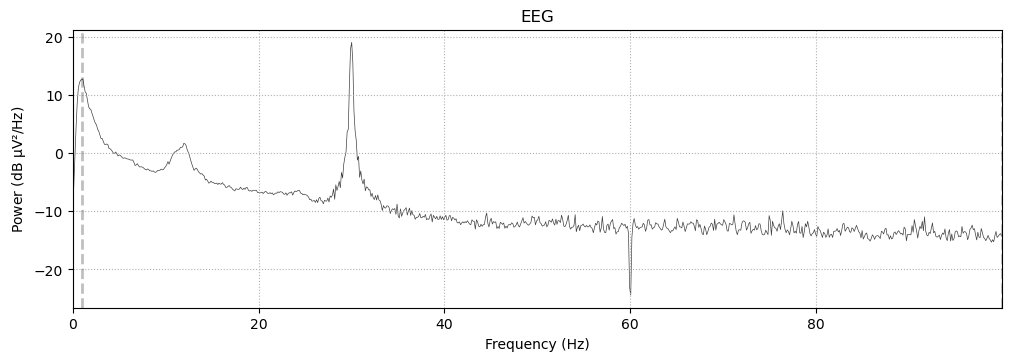

M1
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/var/folders/j8/8nyf6njj5nzfjcv6s23y3nn40000gn/T/ipykernel_40620/882743006.py:19: UserWarning: Zero value in spectrum for channel M1
  raw.compute_psd(picks = chan, fmax=100).plot()
/var/folders/j8/8nyf6njj5nzfjcv6s23y3nn40000gn/T/ipykernel_40620/882743006.py:19: UserWarning: Infinite value in PSD for channel M1.
These channels might be dead.
  raw.compute_psd(picks = chan, fmax=100).plot()
/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


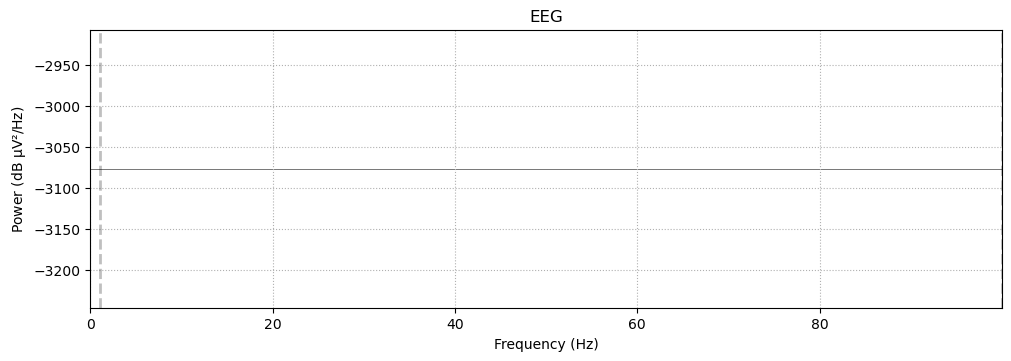

M2
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/var/folders/j8/8nyf6njj5nzfjcv6s23y3nn40000gn/T/ipykernel_40620/882743006.py:19: UserWarning: Zero value in spectrum for channel M2
  raw.compute_psd(picks = chan, fmax=100).plot()
/var/folders/j8/8nyf6njj5nzfjcv6s23y3nn40000gn/T/ipykernel_40620/882743006.py:19: UserWarning: Infinite value in PSD for channel M2.
These channels might be dead.
  raw.compute_psd(picks = chan, fmax=100).plot()
/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


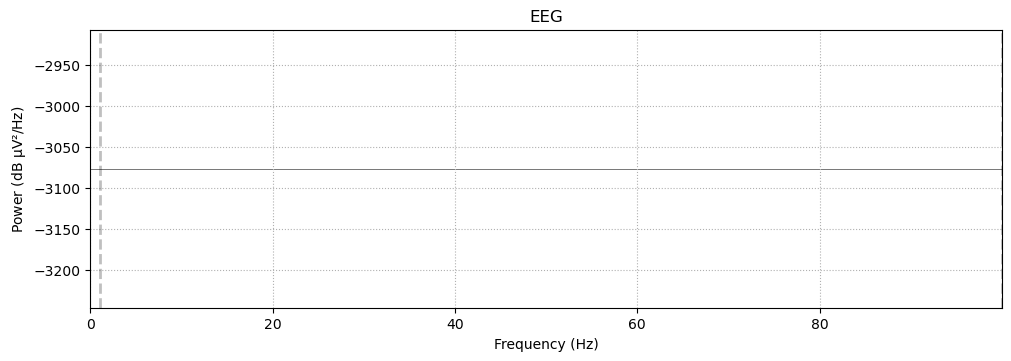

Effective window size : 8.192 (s)


/var/folders/j8/8nyf6njj5nzfjcv6s23y3nn40000gn/T/ipykernel_40620/882743006.py:22: UserWarning: Zero value in spectrum for channels M1, M2
  raw.compute_psd().plot_topomap()


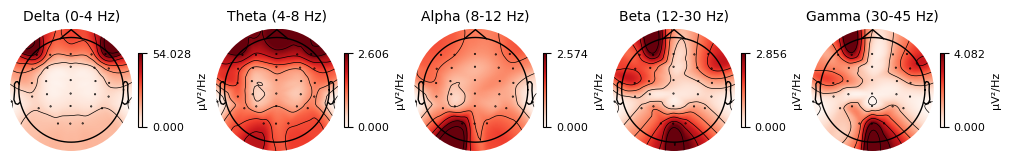

In [32]:
## parameters
# frequency of the eeg recording for audio downsampling
# eeg_freq = 500

# directory
input_dir = work_dir + 'eeg_preprocessed/2_bad_channel_corrected/'

# file name
file = 'KCUE2025_0001_F0_corr_prep.fif'

# read in file
raw = mne.io.read_raw_fif(input_dir + file, preload = True)

raw.drop_channels(['M1', 'M2'])

# if needed, plot a spectrum for each channel
for chan in raw.pick(['eeg']).ch_names:
    print('=====================')
    print(chan)
    raw.compute_psd(picks = chan, fmax=100).plot()
    plt.show()

raw.compute_psd().plot_topomap()
plt.show()

# ICA bad trial correction

In [177]:
#### parameters ####

# directory
input_dir = work_dir + 'eeg_preprocessed/2_bad_channel_corrected/'
output_dir = work_dir + 'eeg_preprocessed/3_ica/'
# create a folder if the folder doesn't exist
# os.makedirs(output_dir, exist_ok=True)

# up to which IC you want to consider
ic_upto = 15
# ic_upto = 99

# run ica on epoched data or continuous data
# ica_input_type = 'continuous'
ica_input_type = 'epoch'

# Epoch window: 
erp_t_start = -0.2; erp_t_end = 0.8


#### ICA ####

# get all file names in the folder
all_input = os.listdir(input_dir)
all_output = os.listdir(output_dir)

# initialize a dictionary for files 
for file in all_input:
    if file.endswith("prep.fif") and (file.split('.')[0]+ '_ica.fif' not in all_output): 

        # read in file
        raw = mne.io.read_raw_fif(input_dir + file, preload=True)
        
        # make a filtered file copy ICA. It works better on signals with 1 Hz high-pass filtered and 100 Hz low-pass filtered
        raw_filt = raw.copy().filter(l_freq = 1, h_freq = 100)
    
        # apply a common average referencing, to comply with the ICLabel requirements
        raw_filt.set_eeg_reference("average")
        
        # initialize ica parameters
        ica = mne.preprocessing.ICA(
            # n_components=0.999999,
            max_iter='auto', # n-1
            # use ‘extended infomax’ method for fitting the ICA, to comply with the ICLabel requirements
            method = 'infomax', 
            fit_params = dict(extended=True),
            random_state = 42,
        )

        # run ica on epochs or continuous
        if ica_input_type=="epoch":
            # get event info for segmentation
            events_from_annot, event_dict = mne.events_from_annotations(raw_filt, verbose='WARNING')
            # segmentation for ERP
            epochs = mne.Epochs(
                raw_filt,
                events = events_from_annot, event_id = event_dict,
                tmin = erp_t_start, tmax = erp_t_end,
                # apply baseline correction
                baseline = None,
                # remove epochs that meet the rejection criteria
                reject = None,
                preload = True,
            )
            # set ica_input
            ica_input = epochs
        elif ica_input_type=="continuous":
            ica_input = raw_filt
    
        #### get ica solution ####
        ica.fit(ica_input, picks = ['eeg'])

        #### ICLabel ####
        ic_labels = label_components(ica_input, ica, method="iclabel")
        # save ica solutions
        ica.save(output_dir + file.split('.')[0]+ '_icaSolution.fif', overwrite=True)
        
        # use ICLabel for automatic IC labeling
        ic_labels = label_components(raw_filt, ica, method="iclabel")
        # save
        with open(output_dir + file.split('.')[0]+ '_icLabels.pickle', 'wb') as f:
            pickle.dump(ic_labels, f)
        
        #### auto select brain AND other ####
        labels = ic_labels["labels"]
        exclude_idx = [
            idx for idx, label in enumerate(labels) if idx<ic_upto and label not in ["brain", "other"]
        ]
    
        # ica.apply() changes the Raw object in-place
        ica.apply(raw, exclude=exclude_idx)
    
        # record the bad ICs in bad_ICs.txt
        with open(output_dir + '/bad_ICs_auto.txt', 'a+') as f:
            _ = f.write(file + '\t' + str(exclude_idx) + '\n')
    
        # save data after ICA
        raw.save(output_dir + file.split('.')[0]+ '_ica.fif')

        # release memory
        del raw, raw_filt, ica_input

Opening raw data file /Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/2_bad_channel_corrected/KCUE2025_0006_VOT_corr_prep.fif...


/var/folders/j8/8nyf6njj5nzfjcv6s23y3nn40000gn/T/ipykernel_4096/428873535.py:32: RuntimeWarning: This filename (/Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/2_bad_channel_corrected/KCUE2025_0006_VOT_corr_prep.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(input_dir + file, preload=True)


    Range : 2663 ... 1197912 =     10.652 ...  4791.648 secs
Ready.
Reading 0 ... 1195249  =      0.000 ...  4780.996 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 825 samples (3.300 s)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.2s


Not setting metadata
1944 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1944 events and 251 original time points ...
0 bad epochs dropped
Fitting ICA to data using 30 channels (please be patient, this may take a while)
Selecting by non-zero PCA components: 27 components
Computing Extended Infomax ICA
Fitting ICA took 113.8s.
Writing ICA solution to /Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/3_ica/KCUE2025_0006_VOT_corr_prep_icaSolution.fif...


...

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Not setting metadata
1968 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1968 events and 251 original time points ...
0 bad epochs dropped
Fitting ICA to data using 30 channels (please be patient, this may take a while)
Selecting by non-zero PCA components: 27 components
Computing Extended Infomax ICA
Fitting ICA took 346.2s.
Writing ICA solution to /Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/3_ica/KCUE2025_0013_VOT_corr_prep_icaSolution.fif...


/var/folders/j8/8nyf6njj5nzfjcv6s23y3nn40000gn/T/ipykernel_4096/428873535.py:76: RuntimeWarning: This filename (/Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/3_ica/KCUE2025_0013_VOT_corr_prep_icaSolution.fif) does not conform to MNE naming conventions. All ICA files should end with -ica.fif, -ica.fif.gz, _ica.fif or _ica.fif.gz
  ica.save(output_dir + file.split('.')[0]+ '_icaSolution.fif', overwrite=True)


Applying ICA to Raw instance
    Transforming to ICA space (27 components)
    Zeroing out 2 ICA components
    Projecting back using 30 PCA components
Writing /Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/3_ica/KCUE2025_0013_VOT_corr_prep_ica.fif


/var/folders/j8/8nyf6njj5nzfjcv6s23y3nn40000gn/T/ipykernel_4096/428873535.py:98: RuntimeWarning: This filename (/Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/3_ica/KCUE2025_0013_VOT_corr_prep_ica.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save(output_dir + file.split('.')[0]+ '_ica.fif')


Closing /Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/3_ica/KCUE2025_0013_VOT_corr_prep_ica.fif
[done]


## spectrum

Opening raw data file /Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/3_ica/KCUE2025_0001_F0_corr_prep_ica.fif...


/var/folders/j8/8nyf6njj5nzfjcv6s23y3nn40000gn/T/ipykernel_40620/1175763631.py:12: RuntimeWarning: This filename (/Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/3_ica/KCUE2025_0001_F0_corr_prep_ica.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(input_dir + file, preload = True)


    Range : 17133 ... 1180934 =     68.532 ...  4723.736 secs
Ready.
Reading 0 ... 1163801  =      0.000 ...  4655.204 secs...
CPz
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


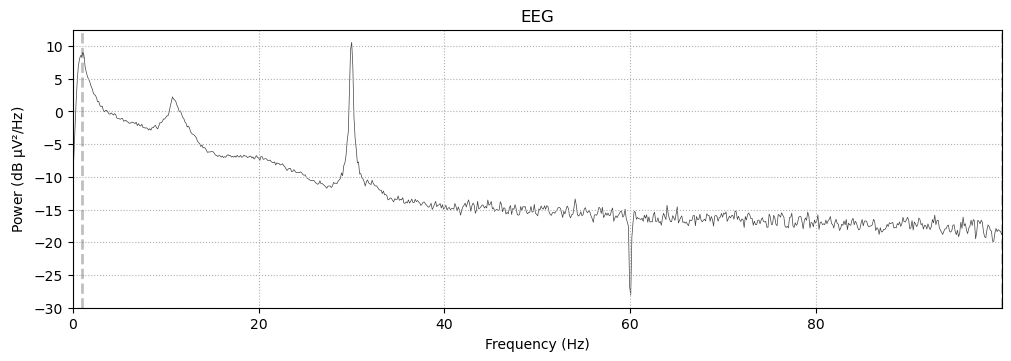

FC4
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


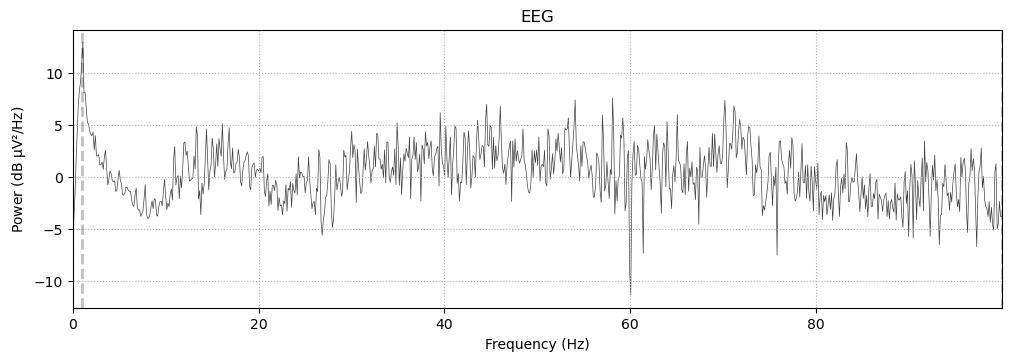

Oz
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


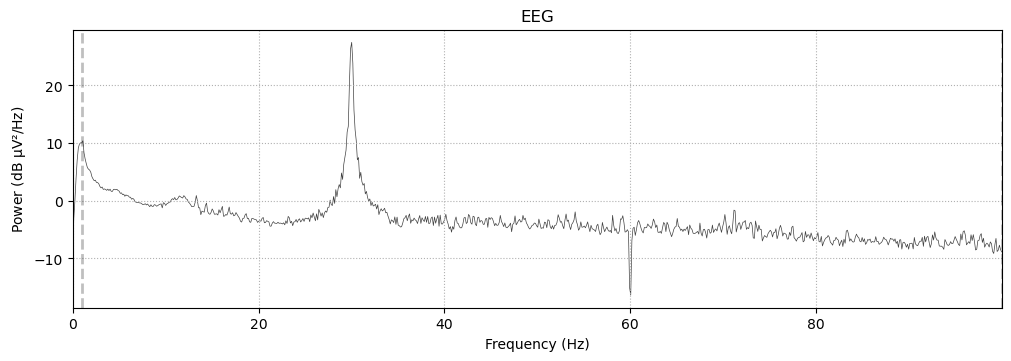

Pz
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


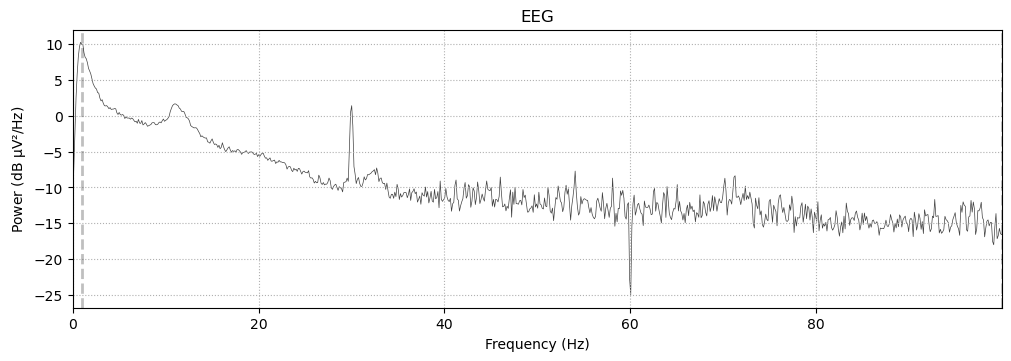

CP4
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


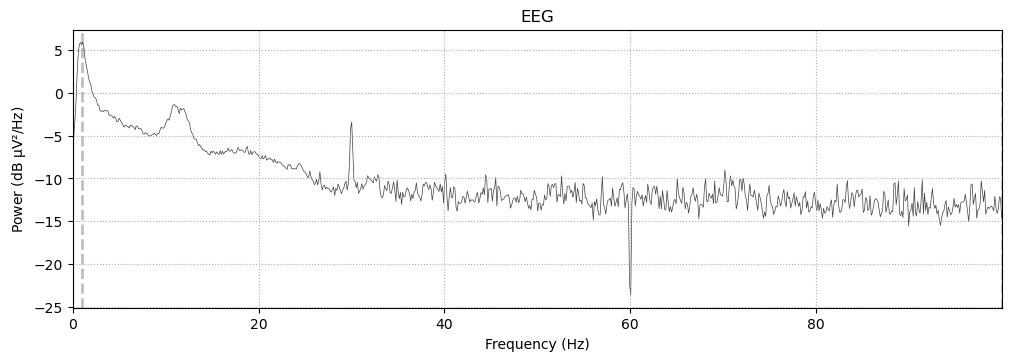

P8
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


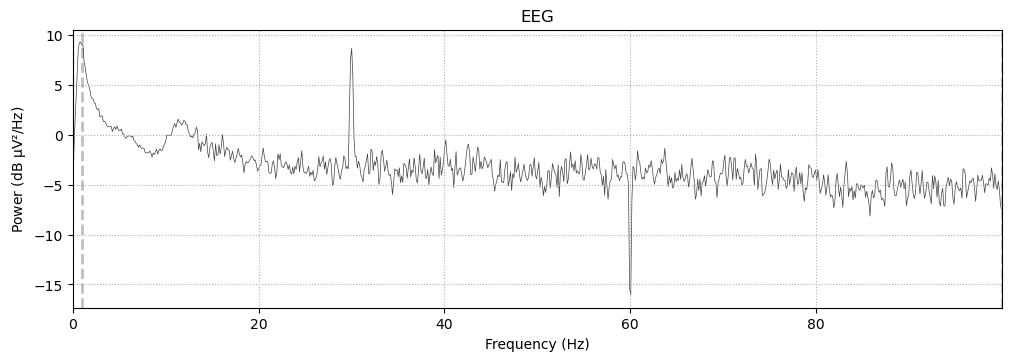

TP8
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


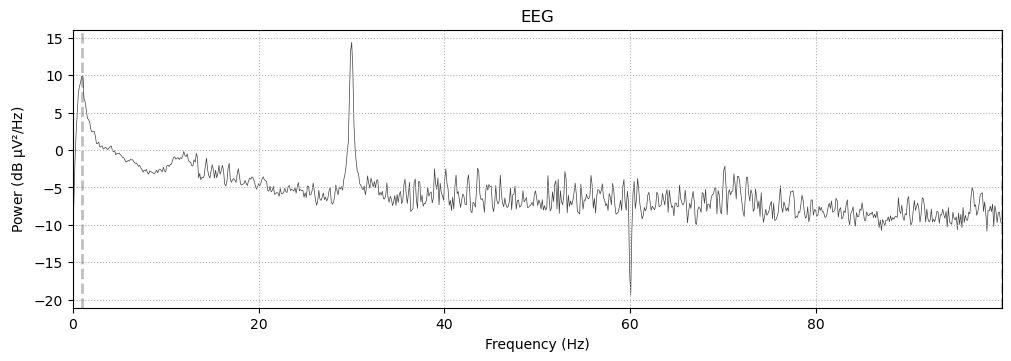

T8
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


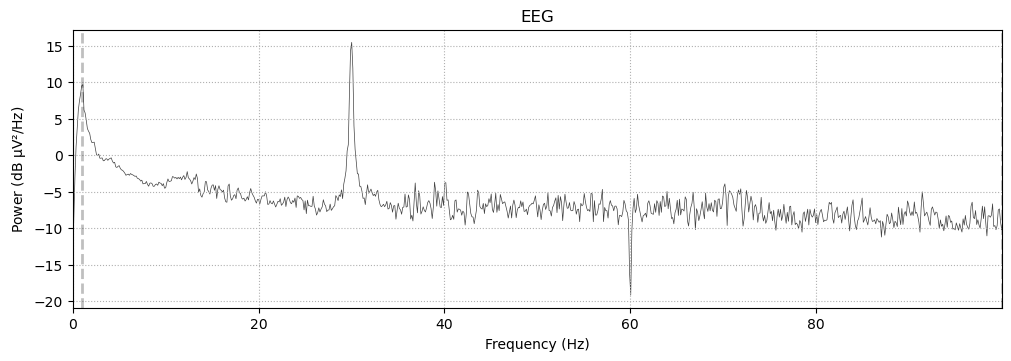

P7
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


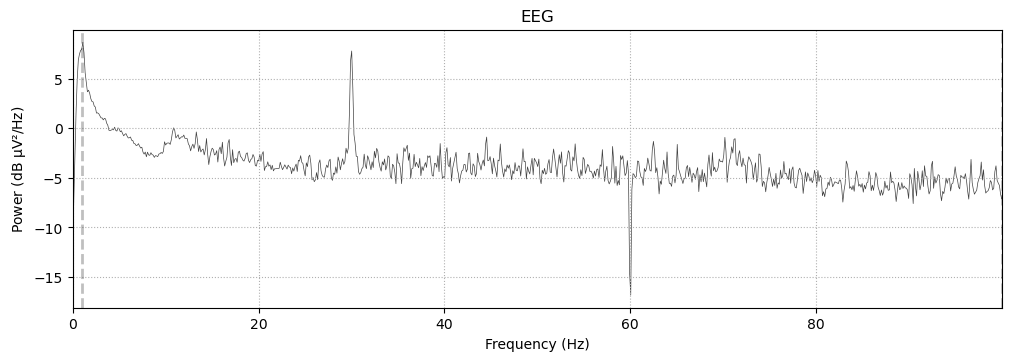

P3
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


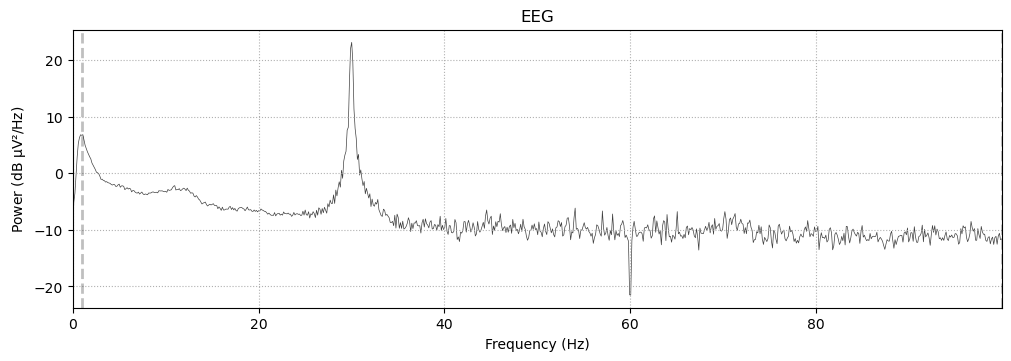

CP3
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


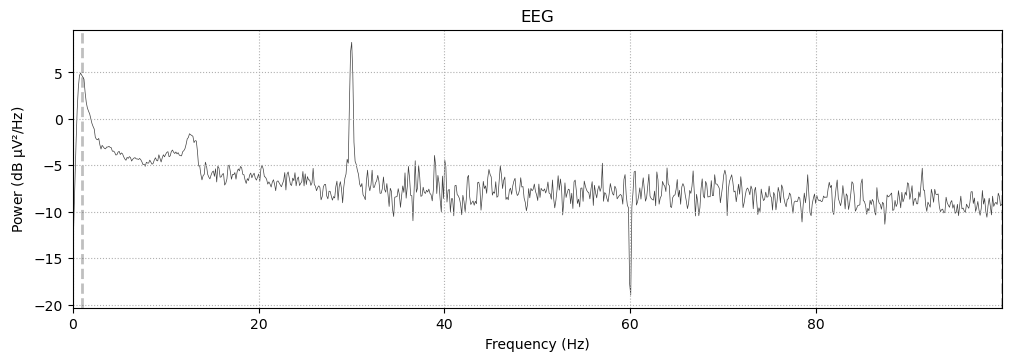

O2
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


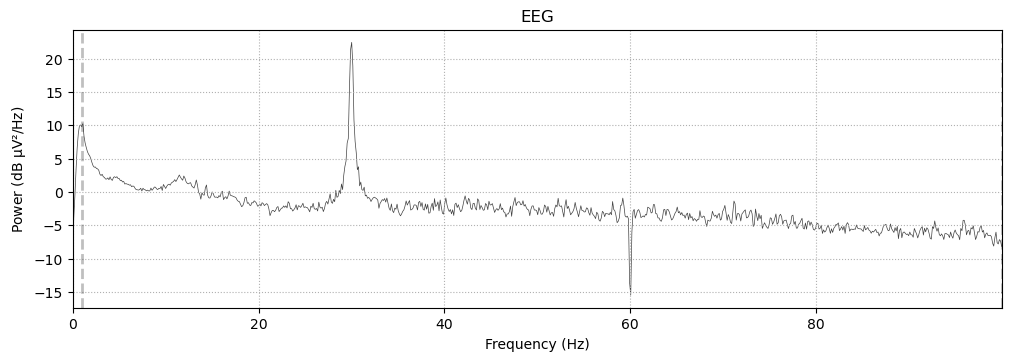

Cz
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


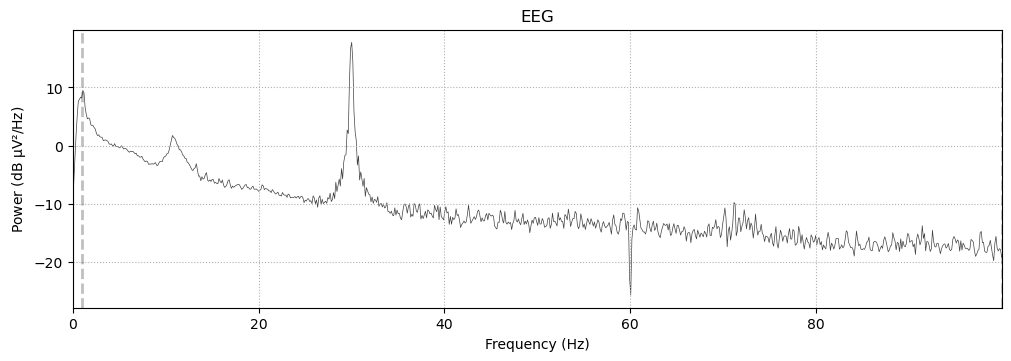

O1
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


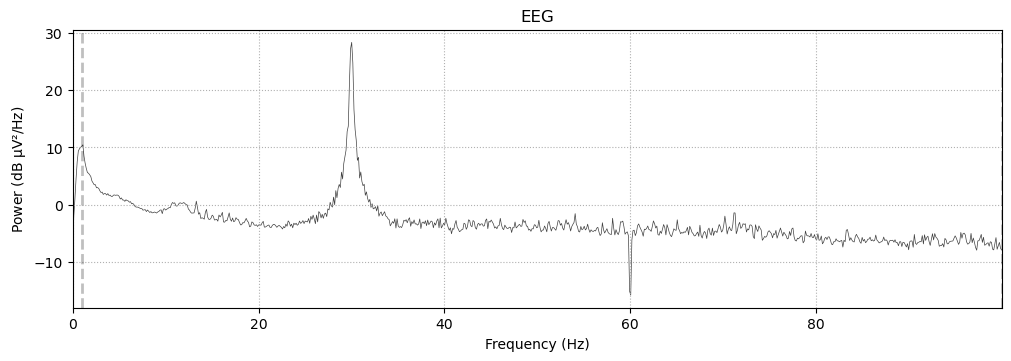

FT8
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


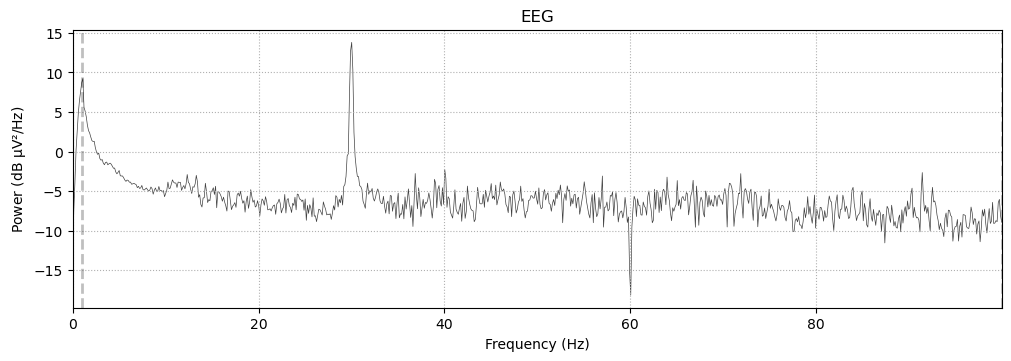

TP7
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


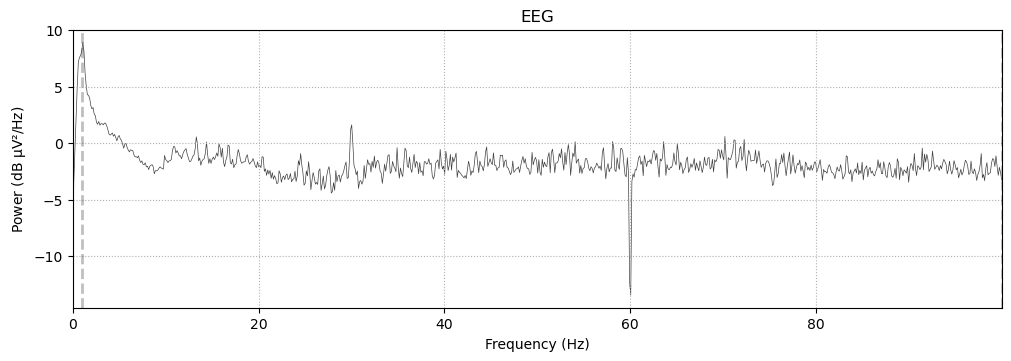

C3
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


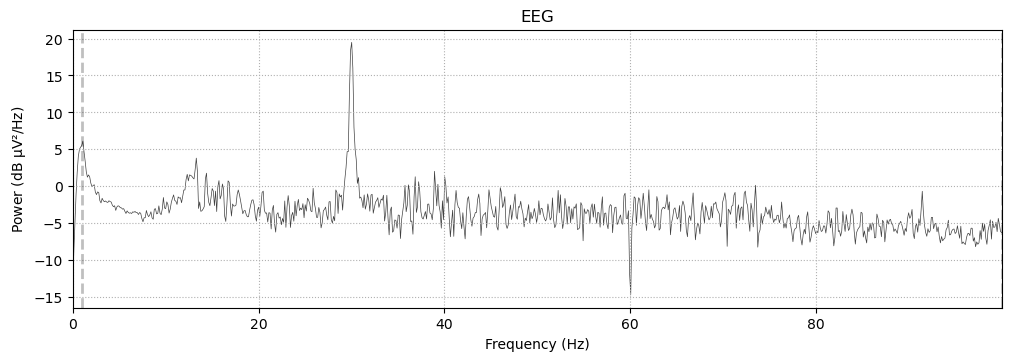

FCz
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


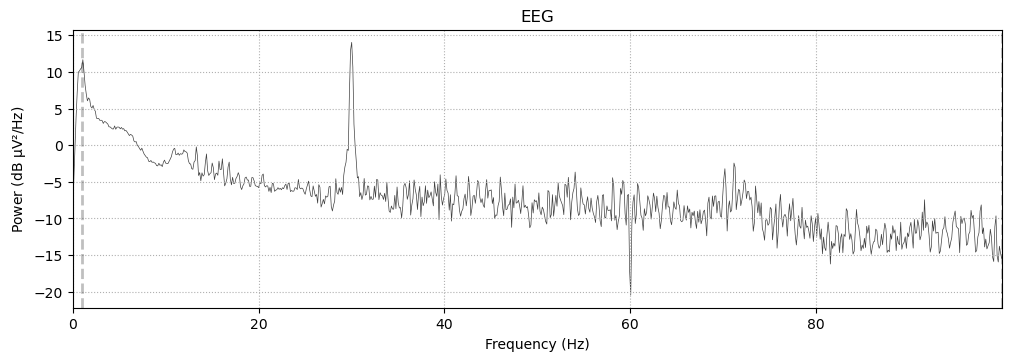

Fz
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


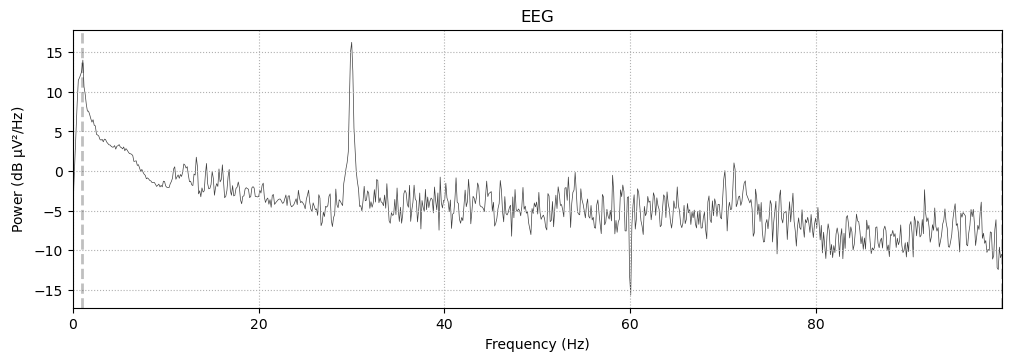

F4
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


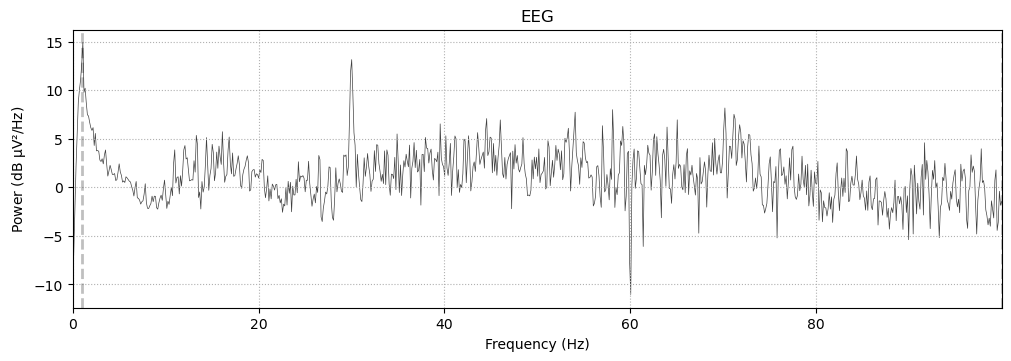

F8
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


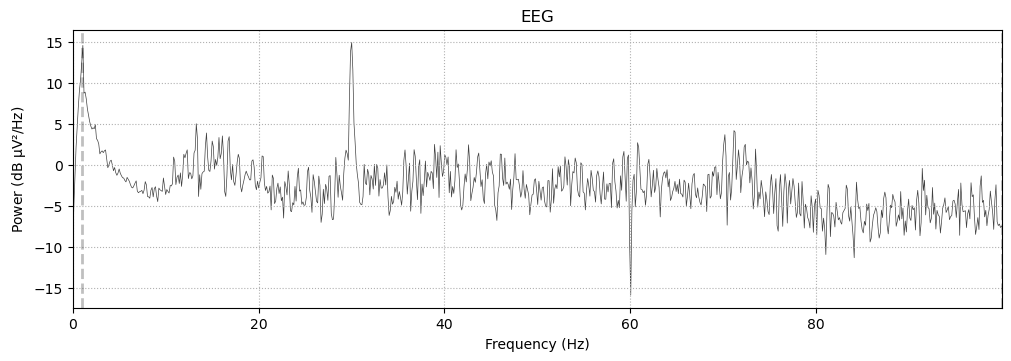

T7
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


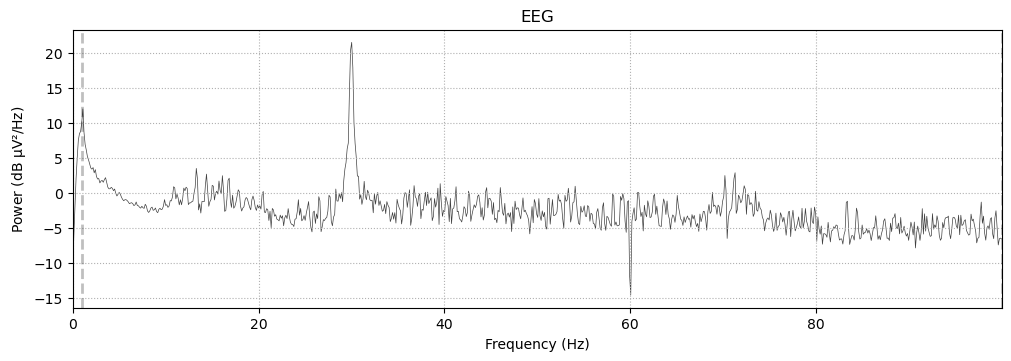

FT7
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


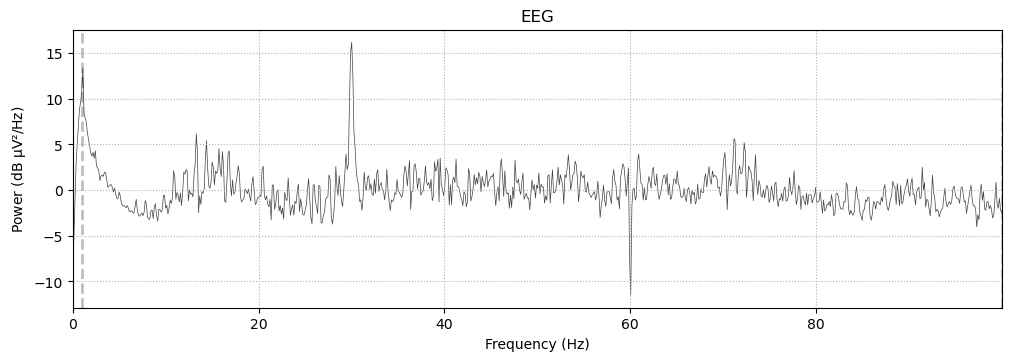

FC3
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


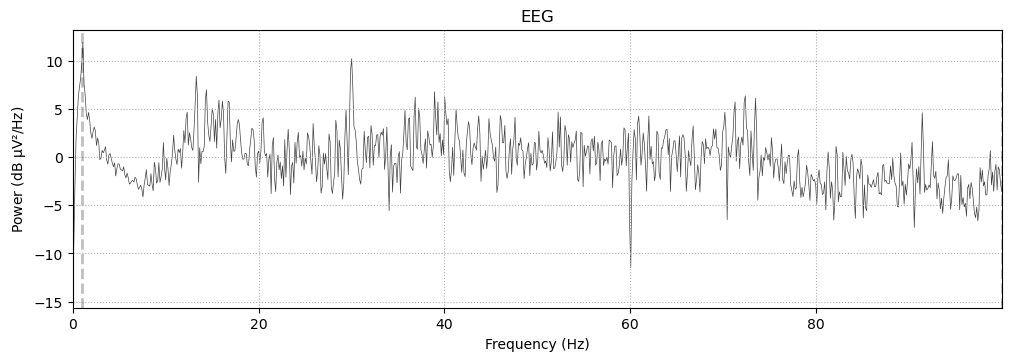

F3
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


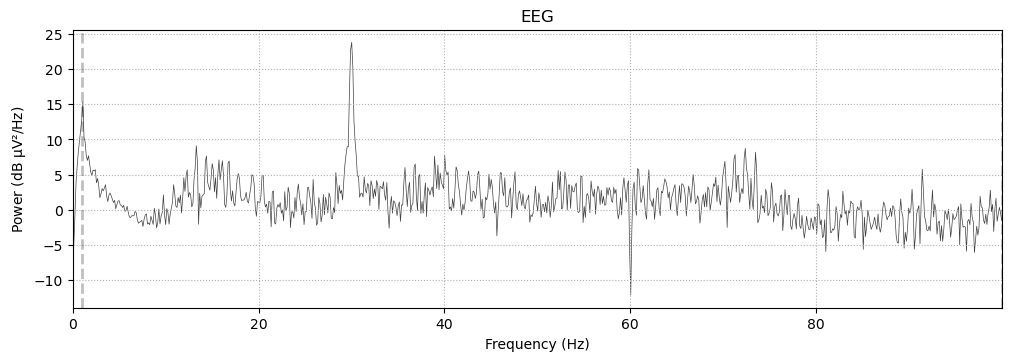

F7
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


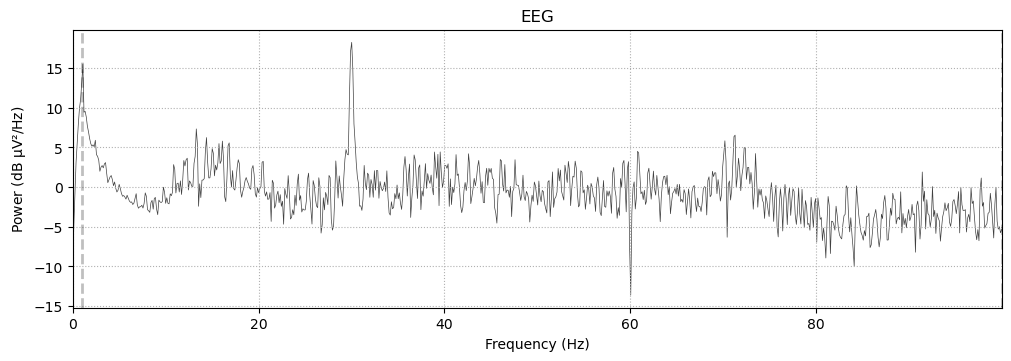

C4
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


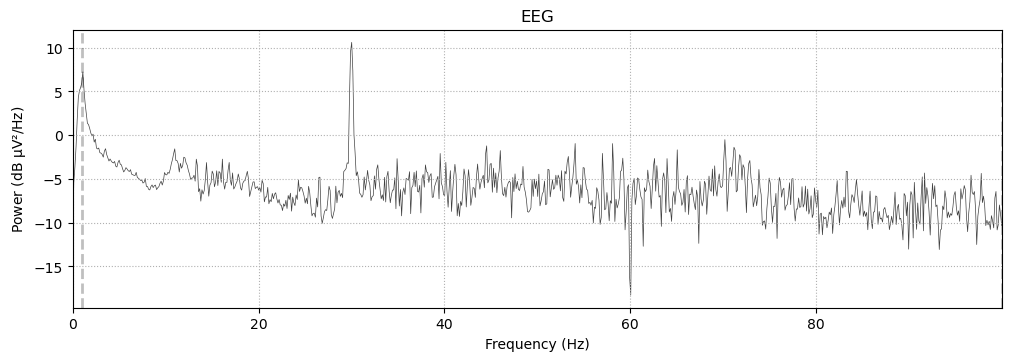

P4
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


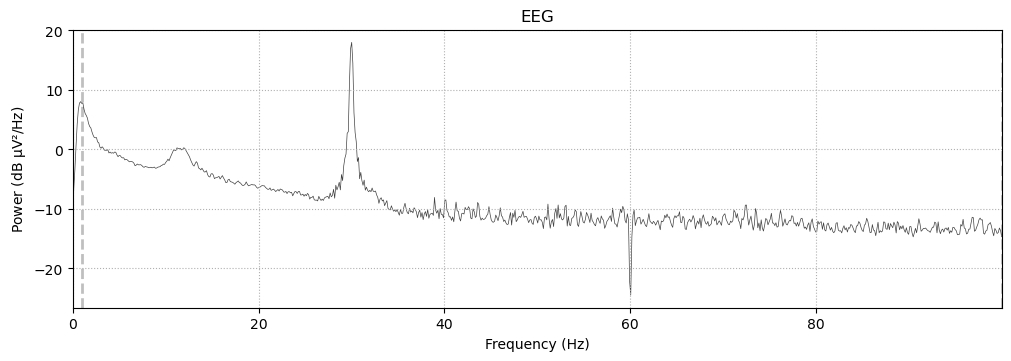

Effective window size : 8.192 (s)


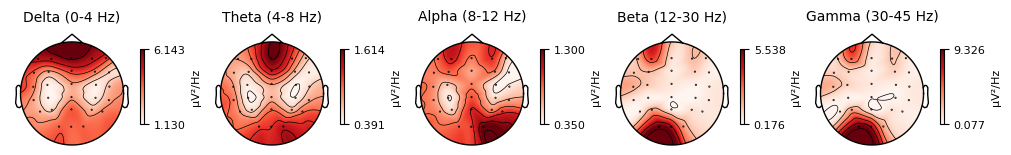

In [33]:
## parameters
# frequency of the eeg recording for audio downsampling
# eeg_freq = 500

# directory
input_dir = work_dir + 'eeg_preprocessed/3_ica/'

# file name
file = 'KCUE2025_0001_F0_corr_prep_ica.fif'

# read in file
raw = mne.io.read_raw_fif(input_dir + file, preload = True)

raw.drop_channels(['M1', 'M2'])

# if needed, plot a spectrum for each channel
for chan in raw.pick(['eeg']).ch_names:
    print('=====================')
    print(chan)
    raw.compute_psd(picks = chan, fmax=100).plot()
    plt.show()

raw.compute_psd().plot_topomap()
plt.show()

# Epochs
segmenting continuous EEG into epochs
- re-reference
- segmentation

In [4]:
#### parameters ####

# directory
input_dir = work_dir + 'eeg_preprocessed/3_ica/'
output_dir = work_dir + 'eeg_preprocessed/4_epochs/' # for ERP 
# create a folder if the folder doesn't exist
# os.makedirs(output_dir, exist_ok=True)

# epoch window: 
erp_t_start = -0.1; erp_t_end = 0.7

# criteria to reject epoch
reject_criteria = dict(eeg = 100e-6)       # 100 µV
# reject_criteria = dict(eeg = 150e-6)       # 150 µV
# reject_criteria = dict(eeg=200e-6)       # 200 µV



#### get epochs ####

# get file names
all_input = os.listdir(input_dir)
all_output = os.listdir(output_dir)


# re-reference, then epoch
for file in all_input:
    
    if file.endswith("ica.fif") and (file.split('_')[2] + '_' + file.split('_')[1] + '_epo.fif' not in all_output):
        
        # read in data
        raw = mne.io.read_raw_fif(input_dir + file, preload = True)
        
        # average-mastoids re-reference
        raw.set_eeg_reference(ref_channels = ['M1', 'M2'])
        
        #### this is for source calculation ####
        # filter the data, optional
        # raw = raw.filter(l_freq=None, h_freq=30) 

        # sphere = mne.make_sphere_model('auto', 'auto', raw.info)
        # src = mne.setup_volume_source_space(sphere=sphere, exclude=30., pos=15.)
        # forward = mne.make_forward_solution(raw.info, trans=None, src=src, bem=sphere)
        # raw = raw.set_eeg_reference('REST', forward=forward)
        ########################################
        
        # get event info for segmentation
        events_from_annot, event_dict = mne.events_from_annotations(raw, verbose='WARNING')

        # shift event time by 20ms
        events_from_annot = mne.event.shift_time_events(events_from_annot, 
                                                        ids=list(event_dict.values()),
                                                        tshift=0.02,
                                                        sfreq = raw.info['sfreq'])
        
        # segmentation for ERP
        epochs = mne.Epochs(
            raw,
            events = events_from_annot, event_id = event_dict,
            tmin = erp_t_start, tmax = erp_t_end,
            # apply baseline correction
            baseline = None,
            # remove epochs that meet the rejection criteria
            reject = reject_criteria,
            preload = True,
        )

        ##########################################################
        #### remove 0-trial events, and log epoch info ####

        ppt = file.split('_')[2] + '_' + file.split('_')[1]
        
        for k, v in event_dict.items():
            
            # good trial count
            trial_count = len(epochs[k])
            
            # remove 0 trial event
            if trial_count==0:
                del epochs.event_id[k]
                
            # good trial rate
            goodTrial_rate = round( trial_count/sum(events_from_annot[:,2]==v), 2 )
            
            # record epoch summary
            with open(output_dir + 'epoch_summary_auto.txt', 'a+') as f:
                _ =f.write(ppt + '\t' + k + '\t' + str(trial_count) + '\t' + str(goodTrial_rate) + '\n')

        # save single participant file
        epochs.save(output_dir + ppt + '_epo.fif', overwrite=True)

Opening raw data file /Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/3_ica/KCUE2025_0013_F0_corr_prep_ica.fif...


/var/folders/j8/8nyf6njj5nzfjcv6s23y3nn40000gn/T/ipykernel_24718/491558734.py:32: RuntimeWarning: This filename (/Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/3_ica/KCUE2025_0013_F0_corr_prep_ica.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(input_dir + file, preload = True)


    Range : 5150 ... 1161118 =     20.600 ...  4644.472 secs
Ready.
Reading 0 ... 1155968  =      0.000 ...  4623.872 secs...
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Not setting metadata
1950 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1950 events and 201 original time points ...
    Rejecting  epoch based on EEG : ['O2']
    Rejecting  epoch based on EEG : ['O2']
    Rejecting  epoch based on EEG : ['O2']
    Rejecting  epoch based on EEG : ['T8']
    Rejecting  epoch based on EEG : ['O2']
    Rejecting  epoch based on EEG : ['O2']
    Rejecting  epoch based on EEG : ['O1']
    Rejecting  epoch based on EEG : ['Oz', 'O1']
    Rejecting  epoch based on EEG : ['O2']
    Rejecting  epoch based on EEG : ['O1']
    Rejecting  epoch based on EEG : ['Oz', 'O1']
    Rejecting  epoch based on EEG : ['O2', 'O1']
    Rejecting  epoch based on EEG : ['Oz', 'O2', 'O1']
    Rejecting  

/var/folders/j8/8nyf6njj5nzfjcv6s23y3nn40000gn/T/ipykernel_24718/491558734.py:32: RuntimeWarning: This filename (/Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/3_ica/KCUE2025_0021_VOT_corr_prep_ica.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(input_dir + file, preload = True)


    Range : 1098 ... 1157993 =      4.392 ...  4631.972 secs
Ready.
Reading 0 ... 1156895  =      0.000 ...  4627.580 secs...
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Not setting metadata
1963 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1963 events and 201 original time points ...
    Rejecting  epoch based on EEG : ['F8', 'T7']
    Rejecting  epoch based on EEG : ['Fz', 'F4', 'F8']
    Rejecting  epoch based on EEG : ['F4']
    Rejecting  epoch based on EEG : ['F8']
    Rejecting  epoch based on EEG : ['F4', 'F8']
    Rejecting  epoch based on EEG : ['F8']
    Rejecting  epoch based on EEG : ['F4', 'F8']
    Rejecting  epoch based on EEG : ['F8']
    Rejecting  epoch based on EEG : ['Oz', 'O2']
    Rejecting  epoch based on EEG : ['F8']
    Rejecting  epoch based on EEG : ['F8']
    Rejecting  epoch based on EEG : ['F8']
    Rejecting  epoch based on EEG : ['F8']
    Rejec

...

    Range : 34557 ... 1209040 =    138.228 ...  4836.160 secs
Ready.
Reading 0 ... 1174483  =      0.000 ...  4697.932 secs...
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Not setting metadata
1982 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1982 events and 201 original time points ...
    Rejecting  epoch based on EEG : ['FT7']
    Rejecting  epoch based on EEG : ['FT7']
    Rejecting  epoch based on EEG : ['FT7']
    Rejecting  epoch based on EEG : ['FT7']
    Rejecting  epoch based on EEG : ['FT7']
    Rejecting  epoch based on EEG : ['FT7']
    Rejecting  epoch based on EEG : ['FT7']
    Rejecting  epoch based on EEG : ['FT7', 'F3']
    Rejecting  epoch based on EEG : ['FT7']
    Rejecting  epoch based on EEG : ['TP7', 'FT7']
    Rejecting  epoch based on EEG : ['TP7', 'FT7']
    Rejecting  epoch based on EEG : ['TP7', 'FT7']
    Rejecting  epoch based on EEG : ['FC4', 'CP4

/var/folders/j8/8nyf6njj5nzfjcv6s23y3nn40000gn/T/ipykernel_24718/491558734.py:32: RuntimeWarning: This filename (/Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/3_ica/KCUE2025_0002_VOT_corr_prep_ica.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(input_dir + file, preload = True)


    Range : 32492 ... 1197802 =    129.968 ...  4791.208 secs
Ready.
Reading 0 ... 1165310  =      0.000 ...  4661.240 secs...
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Not setting metadata
1925 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1925 events and 201 original time points ...
    Rejecting  epoch based on EEG : ['P7', 'T7']
    Rejecting  epoch based on EEG : ['P8', 'P7']
    Rejecting  epoch based on EEG : ['Oz', 'O1', 'F4']
    Rejecting  epoch based on EEG : ['Oz', 'O2', 'O1']
    Rejecting  epoch based on EEG : ['Oz', 'O2']
    Rejecting  epoch based on EEG : ['FC4', 'Oz', 'CP4', 'P8', 'TP8', 'T8', 'O2', 'O1', 'FT8', 'F4', 'F8', 'T7', 'FT7', 'FC3', 'F3', 'F7', 'C4']
    Rejecting  epoch based on EEG : ['FT7']
    Rejecting  epoch based on EEG : ['P7']
    Rejecting  epoch based on EEG : ['O1']
    Rejecting  epoch based on EEG : ['Oz', 'O2', 'O1']
    Rejecting  e

/var/folders/j8/8nyf6njj5nzfjcv6s23y3nn40000gn/T/ipykernel_24718/491558734.py:32: RuntimeWarning: This filename (/Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/3_ica/KCUE2025_0010_F0_corr_prep_ica.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(input_dir + file, preload = True)


    Range : 2744 ... 1144225 =     10.976 ...  4576.900 secs
Ready.
Reading 0 ... 1141481  =      0.000 ...  4565.924 secs...
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Not setting metadata
1976 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1976 events and 201 original time points ...
    Rejecting  epoch based on EEG : ['O2']
    Rejecting  epoch based on EEG : ['F3']
    Rejecting  epoch based on EEG : ['F3']
    Rejecting  epoch based on EEG : ['F3']
    Rejecting  epoch based on EEG : ['O2']
    Rejecting  epoch based on EEG : ['P7']
    Rejecting  epoch based on EEG : ['F3']
    Rejecting  epoch based on EEG : ['TP7', 'T7', 'FT7', 'F7']
    Rejecting  epoch based on EEG : ['F3']
    Rejecting  epoch based on EEG : ['TP7', 'T7', 'FT7']
    Rejecting  epoch based on EEG : ['O2']
    Rejecting  epoch based on EEG : ['O1']
    Rejecting  epoch based on EEG : ['Oz', 'P7', 'O2',

## spectrum

Reading /Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/4_epochs/F0_0001_epo.fif ...
    Found the data of interest:
        t =    -100.00 ...     700.00 ms
        0 CTF compensation matrices available
Not setting metadata
1904 matching events found
No baseline correction applied
0 projection items activated
CPz
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


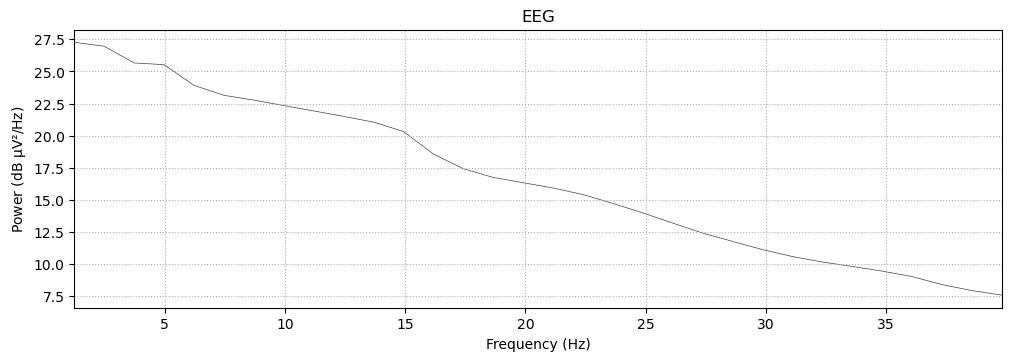

FC4
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


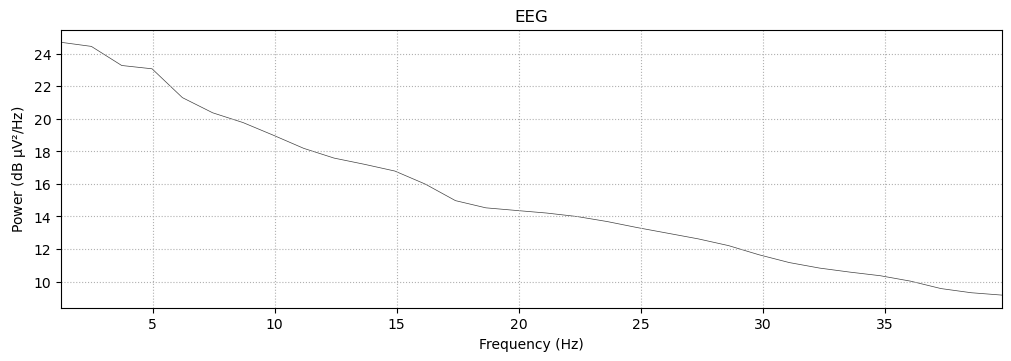

Oz
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


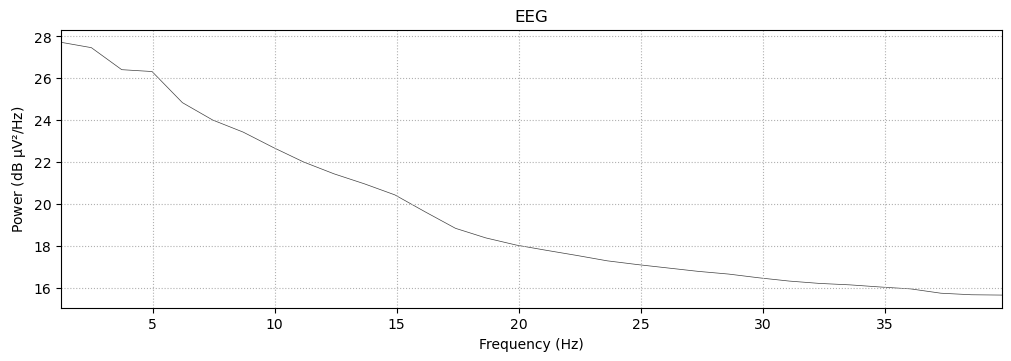

Pz
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


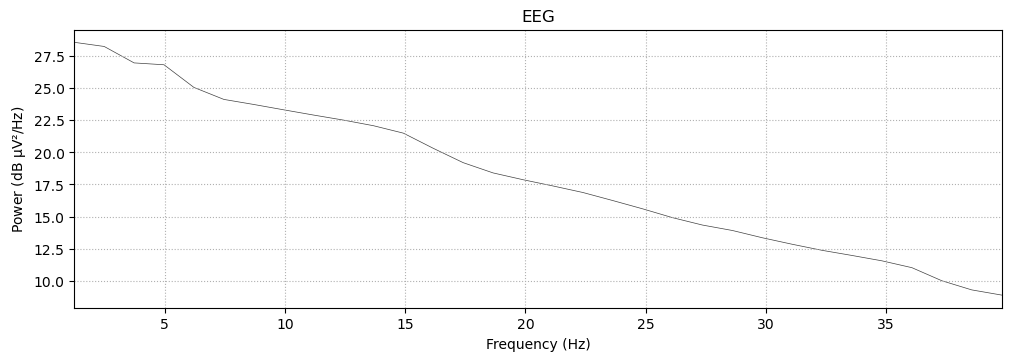

CP4
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


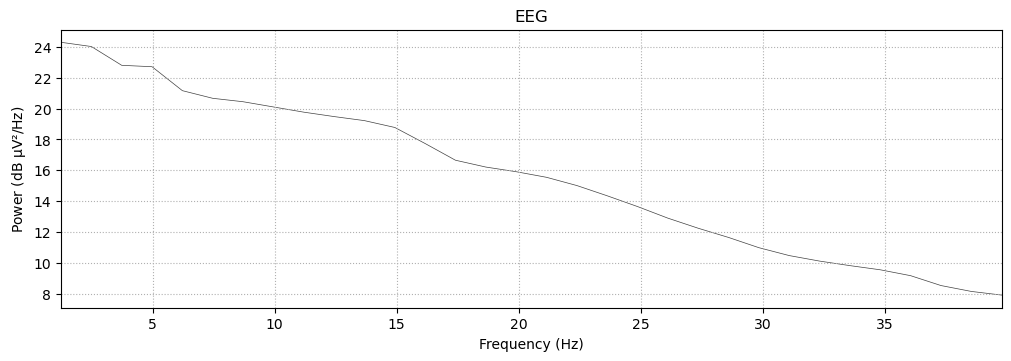

P8
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


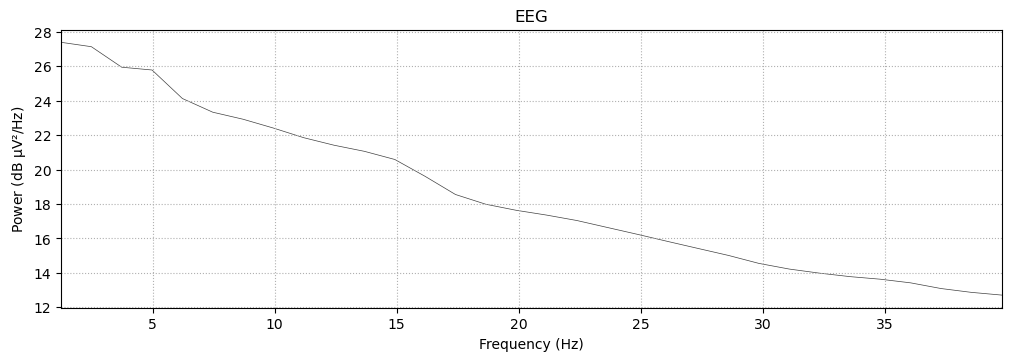

TP8
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


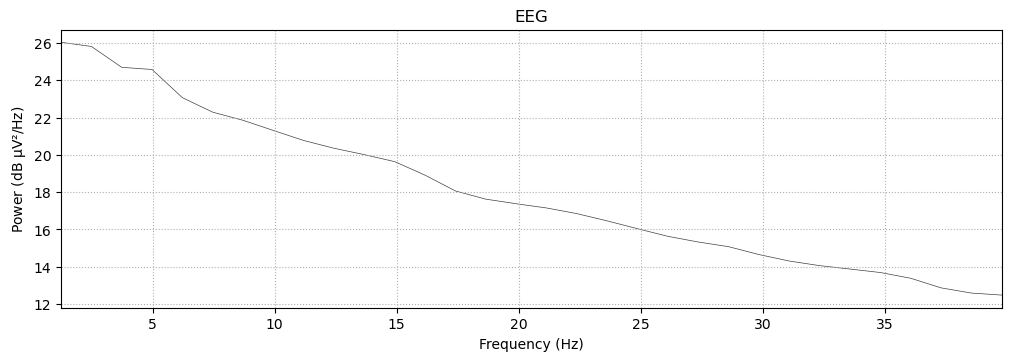

T8
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


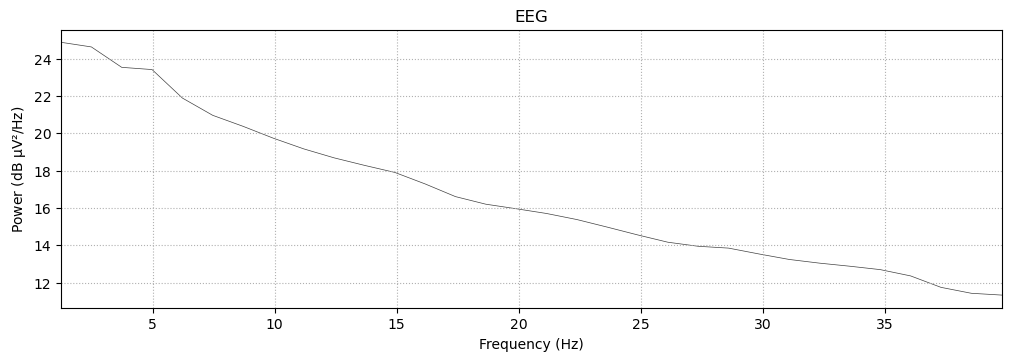

P7
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


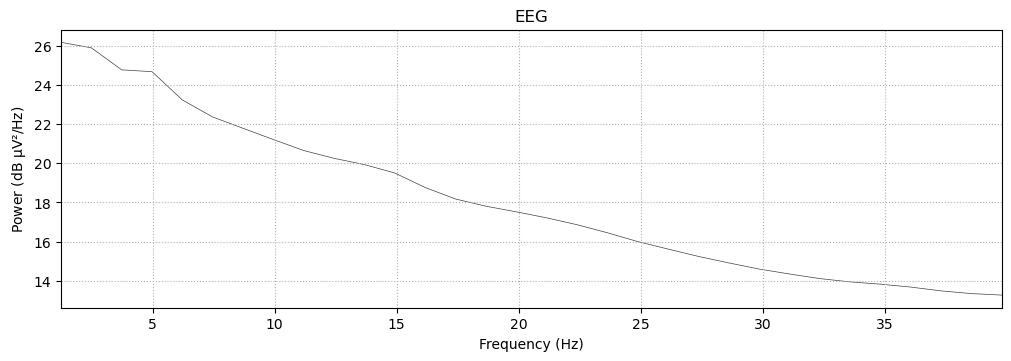

P3
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


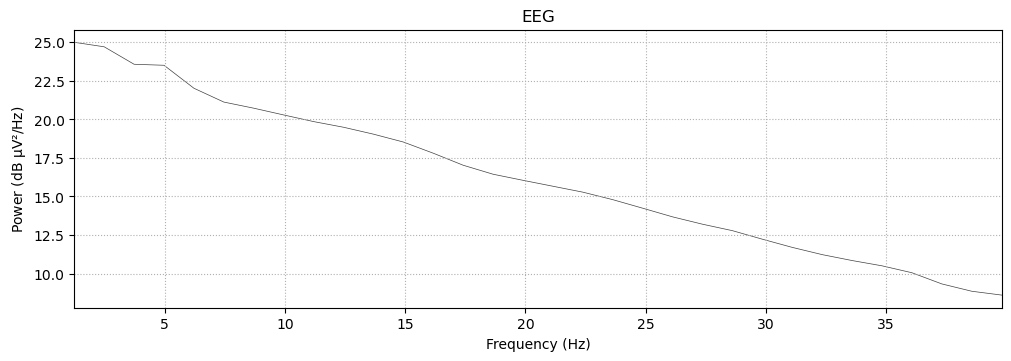

CP3
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


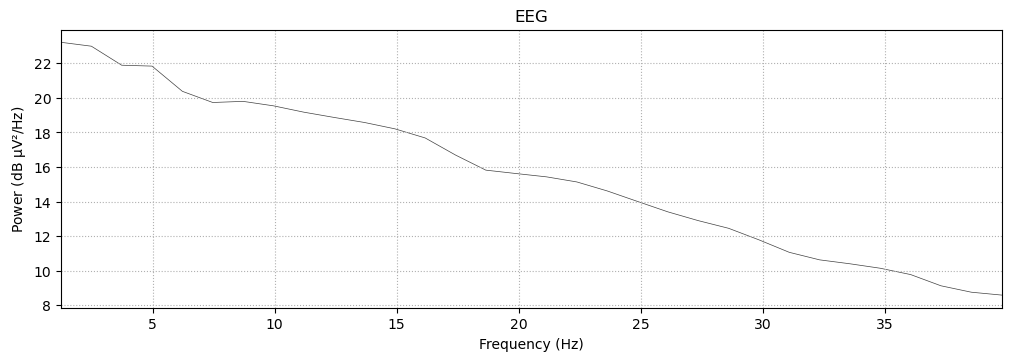

O2
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


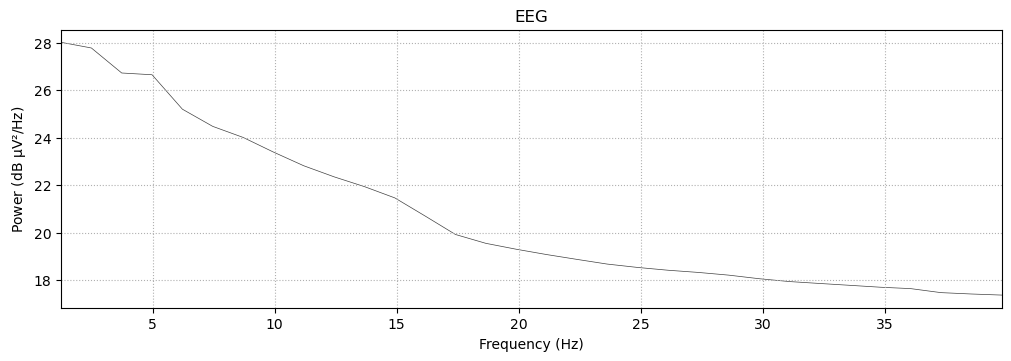

Cz
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


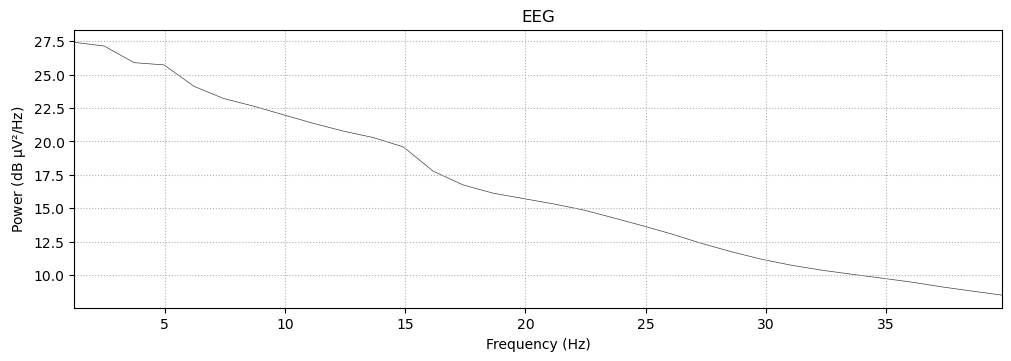

O1
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


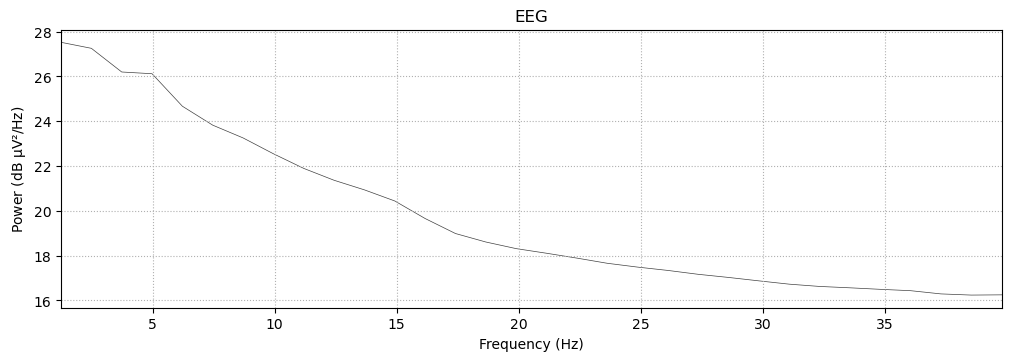

FT8
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


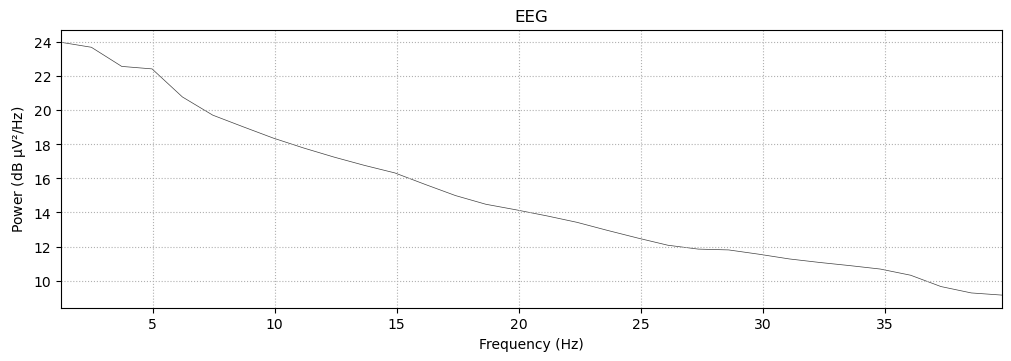

TP7
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


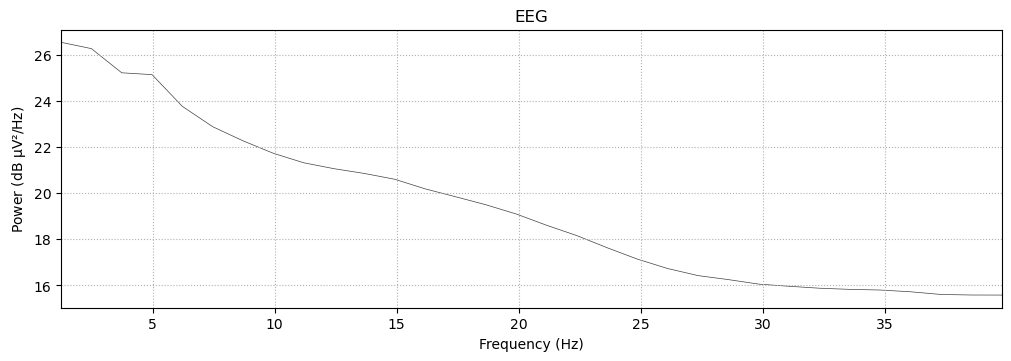

C3
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


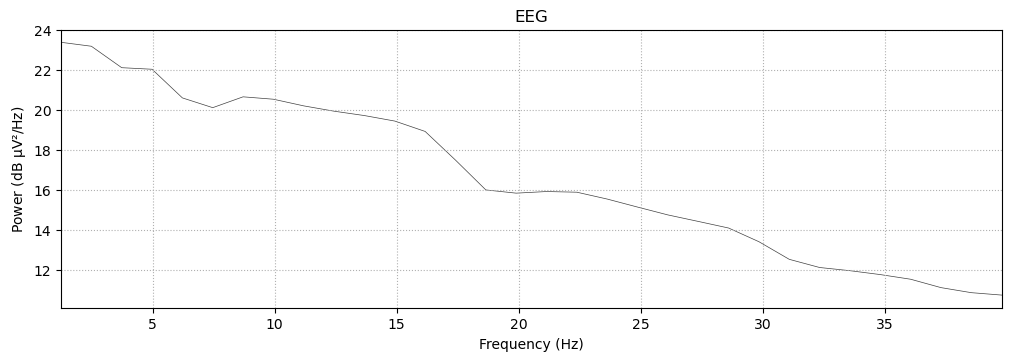

FCz
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


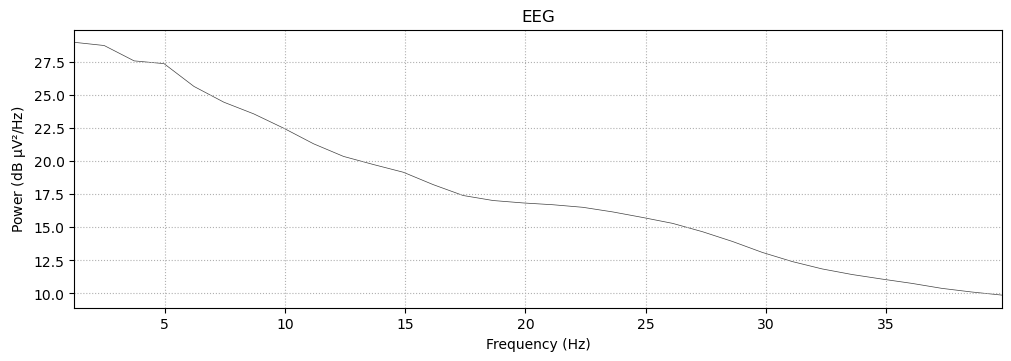

Fz
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


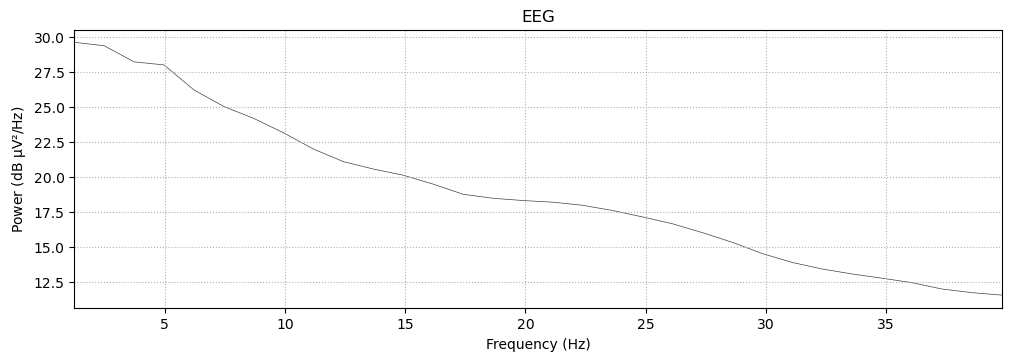

F4
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


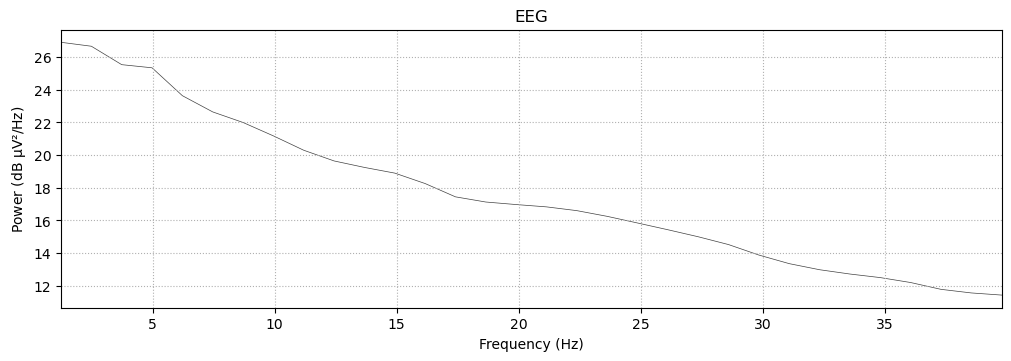

F8
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


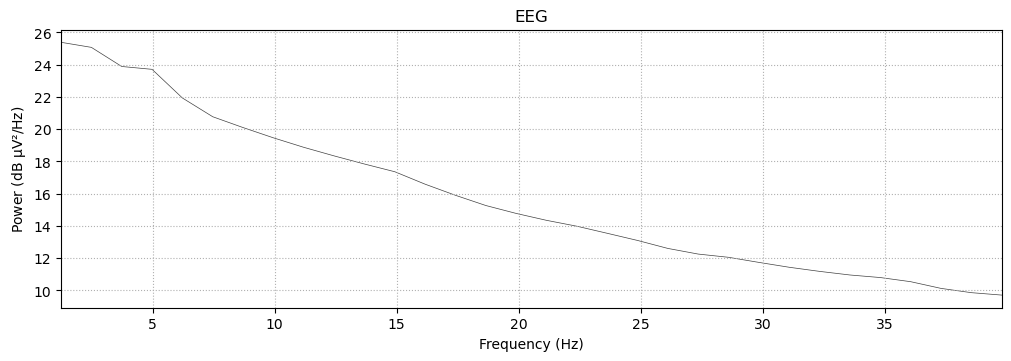

T7
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


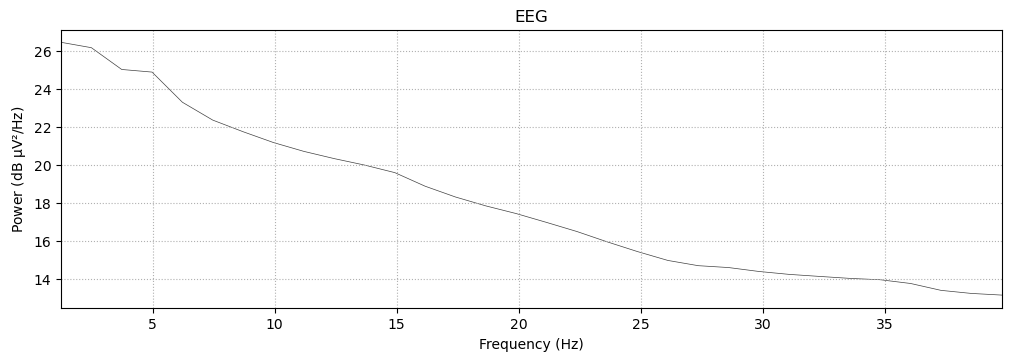

FT7
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


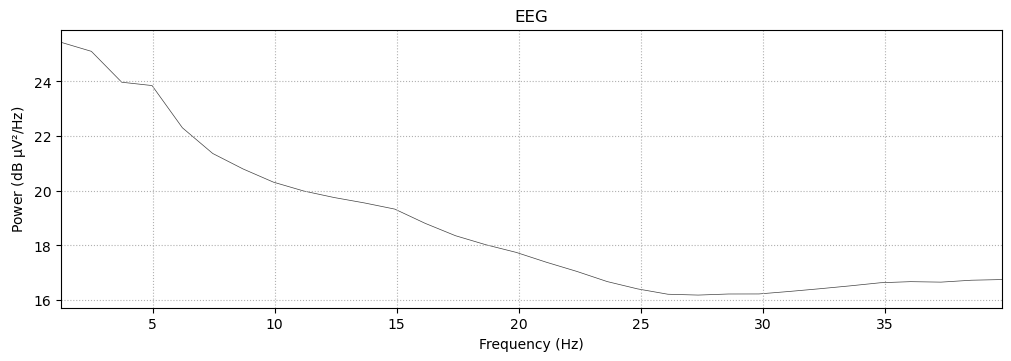

FC3
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


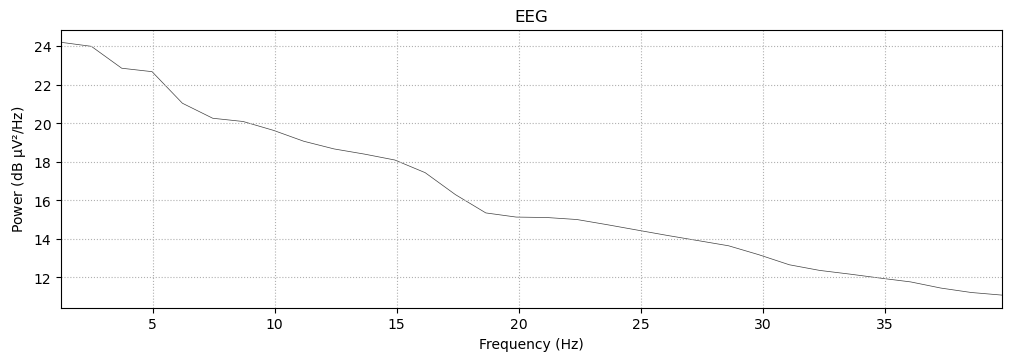

F3
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


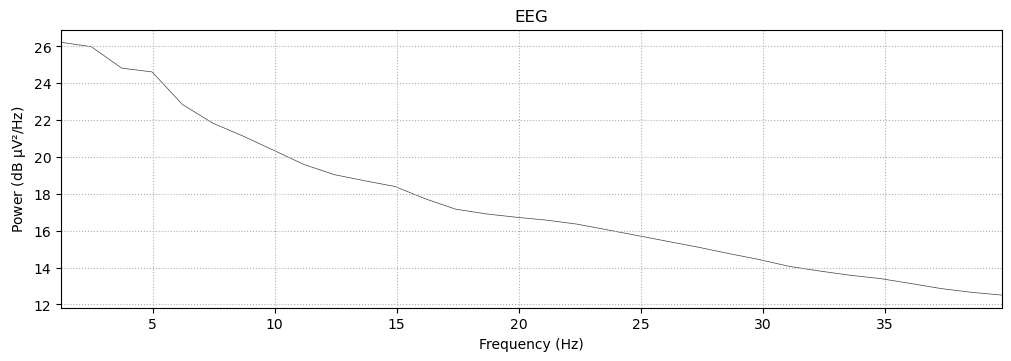

F7
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


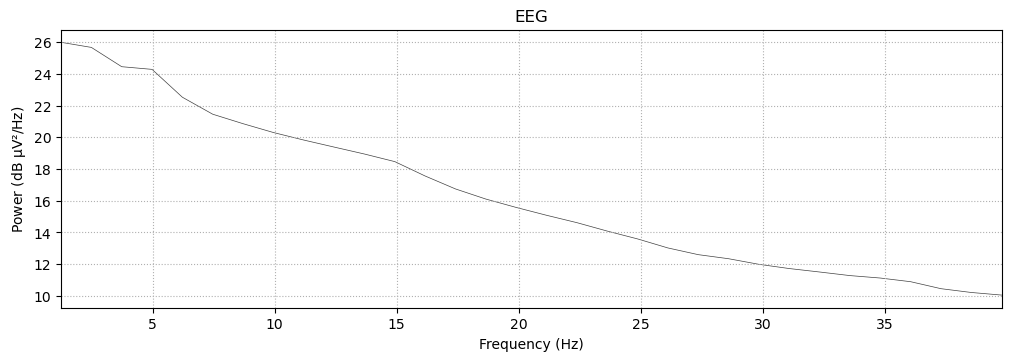

C4
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


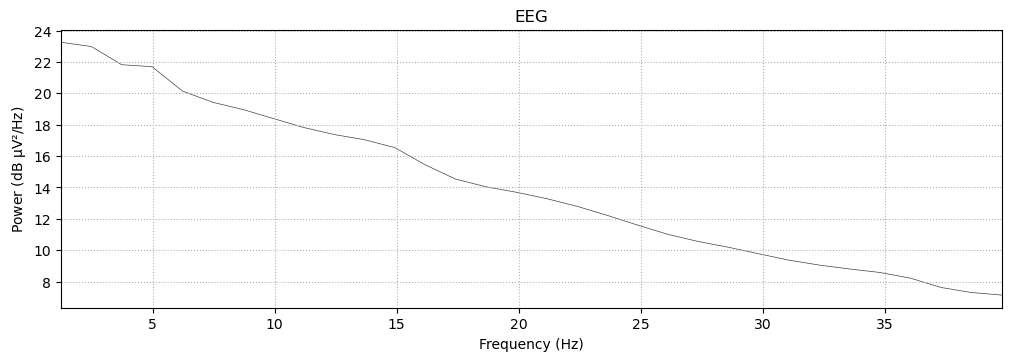

P4
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Need more than one channel to make topography for eeg. Disabling interactivity.


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


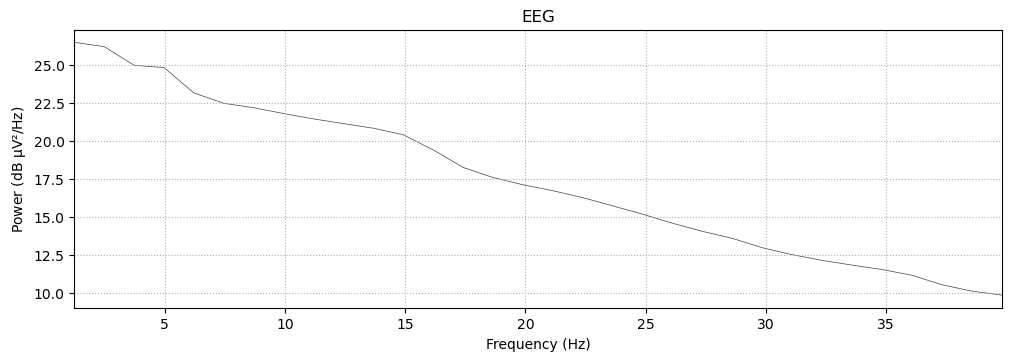

    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...


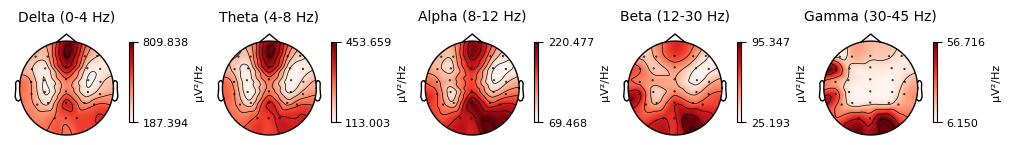

In [41]:
## parameters
# frequency of the eeg recording for audio downsampling
# eeg_freq = 500

# directory
input_dir = work_dir + 'eeg_preprocessed/4_epochs/'

# file name
file = 'F0_0001_epo.fif'

# read in file
epochs = mne.read_epochs(input_dir + file, preload = True)

epochs.drop_channels(['M1', 'M2'])

# if needed, plot a spectrum for each channel
for chan in epochs.pick(['eeg']).ch_names:
    print('=====================')
    print(chan)
    epochs.compute_psd(picks = chan, fmin=1,fmax=40).plot()
    plt.show()

epochs.compute_psd().plot_topomap()
plt.show()

# Evokeds

In [5]:
#### parameters ####

# directory
input_dir = work_dir + 'eeg_preprocessed/4_epochs/'
output_dir = work_dir + 'eeg_preprocessed/5_evokeds/'
# create a folder if the folder doesn't exist
# os.makedirs(output_dir, exist_ok=True)

# condition
conditions = [
    'dorsal_highStan_lowDevi_stan', 
    'dorsal_highStan_lowDevi_devi', 
    'dorsal_lowStan_highDevi_stan', 
    'dorsal_lowStan_highDevi_devi', 
    'glottal_highStan_lowDevi_stan', 
    'glottal_highStan_lowDevi_devi', 
    'glottal_lowStan_highDevi_stan', 
    'glottal_lowStan_highDevi_devi',
]


exclude_ppts = [
]

erp_baseline = (-0.1, 0)

#### get ERP ####

# get file names
all_input = os.listdir(input_dir)
all_output = os.listdir(output_dir)


# for each file
for file in all_input:
    
    if file.endswith("_epo.fif") and (file.rsplit('_', 1)[0]+'_ave.fif' not in all_output):
        
        # exclude bad participants
        if file.rsplit('_', 1)[0] in exclude_ppts:
            continue
        
        # read in data
        epochs = mne.read_epochs(input_dir + file, preload = True)

        # get erp for each condition
        evoked_list = []
        for cond in conditions:
            
            # average | get ERP for each condition
            evoked = epochs[cond].average(by_event_type=False)

            # add condition label
            evoked.comment = cond

            # apply baseline
            evoked.apply_baseline(baseline=erp_baseline)

            # append
            evoked_list.append(evoked)
        
        # save
        mne.write_evokeds(output_dir + file.rsplit('_', 1)[0] + '_ave.fif', evoked_list)
    
        # reduce memory usage
        del epochs, evoked, evoked_list

Reading /Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/4_epochs/VOT_0008_epo.fif ...
    Found the data of interest:
        t =    -100.00 ...     700.00 ms
        0 CTF compensation matrices available
Not setting metadata
1805 matching events found
No baseline correction applied
0 projection items activated
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Reading /Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/4_epochs/VOT_0018_epo.fif ...
    Found the data of interest:
        t =    -100.00 ...     700.00 ms
        0 CTF compensation matrices available
Not setting metada

# TRF
segmenting continuous EEG into epochs for ERSP analysis
- re-reference
- segmentation

In [3]:
# directory
input_dir = work_dir + 'eeg_preprocessed/3_ica/'
output_dir = work_dir + 'eeg_preprocessed/4_tfr_evokeds_unnormalized/'

# Epoch window: 
epoch_t_start = -1; epoch_t_end = 2
v
# criteria to reject epoch
reject_criteria = dict(eeg = 100e-6)       # 100 µV
# reject_criteria = dict(eeg = 150e-6)       # 150 µV
# reject_criteria = dict(eeg = 200e-6)       # 200 µV

exclude_ppts = [
]

tfr_method = 'morlet'

# frequencies
freq_start = 3
freq_end = 30
n_freq = 28
freqs = np.linspace(start=freq_start, stop=freq_end, num=n_freq)

# cycles
cycl_start = 3
cycl_step = 0.8
n_cycl = n_freq
n_cycles = np.linspace(start=cycl_start, stop=cycl_start+cycl_step*(n_cycl-1), num=n_cycl)

condition_list = [
    'dorsal_highStan_lowDevi_stan',
    'dorsal_lowStan_highDevi_stan',
    'glottal_highStan_lowDevi_stan',
    'glottal_lowStan_highDevi_stan',
]

# initialize a list for subjects with too many bad trials
all_input = os.listdir(input_dir)
all_output = os.listdir(output_dir)


#### re-reference, and epoch ####
for file in all_input:
    
    if file.endswith("ica.fif"):

        # get participant info
        ppt = file.split('_')[2] + '_' + file.split('_')[1]

        # skip bad participants
        if (ppt + '_tfr.hdf5' in all_output) or (ppt in exclude_ppts):
            continue
        
        # read in data
        raw = mne.io.read_raw_fif(input_dir + file, preload = True)
        
        # average-mastoids re-reference
        raw.set_eeg_reference(ref_channels = ['M1', 'M2'])    
        
        # get event info for segmentation
        events_from_annot, event_dict = mne.events_from_annotations(raw, verbose='WARNING')

        # shift event time by 20ms
        events_from_annot = mne.event.shift_time_events(events_from_annot, 
                                                        ids=list(event_dict.values()),
                                                        tshift=0.02,
                                                        sfreq = raw.info['sfreq'])
        
        # segmentation for ERP
        epochs = mne.Epochs(
            raw,
            events = events_from_annot, event_id = event_dict,
            tmin = epoch_t_start, tmax = epoch_t_end,
            # apply baseline correction
            baseline = None,
            # remove epochs that meet the rejection criteria
            reject = reject_criteria,
            preload = True,
        )

        # for each event, remove 0 trial events, record info, and check if a subject is bad
        for k, v in event_dict.items():
            
            # good trial count
            trial_count = len(epochs[k])
            
            # remove 0 trial event
            if trial_count==0:
                del epochs.event_id[k]
                
            # good trial rate
            goodTrial_rate = round( trial_count/sum(events_from_annot[:,2]==v), 2 )
            
            # record epoch summary
            with open(output_dir + 'epoch_summary.txt', 'a+') as f:
                _ =f.write(ppt + '\t' + k + '\t' + str(trial_count) + '\t' + str(goodTrial_rate) + '\n')


        # ERSP
        # initialize tfrs list
        tfrs = []
        
        for condition in condition_list:
            # compute ERSP
            power = epochs[condition].compute_tfr(
                method=tfr_method,
                freqs=freqs,
                n_cycles=n_cycles,
                # return_itc=True,
            )
            
            # average
            power = power.average(method = 'mean', dim = 'epochs')

            # add comment
            power.comment = condition

            # append
            tfrs.append(power)
            
        # save single subject file
        mne.time_frequency.write_tfrs(fname=output_dir + ppt + '_tfr.hdf5', 
                                      tfr=tfrs)

        # release memory
        del power, tfrs

Opening raw data file /Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/3_ica/KCUE2025_0013_F0_corr_prep_ica.fif...


/var/folders/j8/8nyf6njj5nzfjcv6s23y3nn40000gn/T/ipykernel_12168/3695957882.py:55: RuntimeWarning: This filename (/Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/3_ica/KCUE2025_0013_F0_corr_prep_ica.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(input_dir + file, preload = True)


    Range : 5150 ... 1161118 =     20.600 ...  4644.472 secs
Ready.
Reading 0 ... 1155968  =      0.000 ...  4623.872 secs...
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Not setting metadata
1950 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1950 events and 751 original time points ...
    Rejecting  epoch based on EEG : ['T8']
    Rejecting  epoch based on EEG : ['T8']
    Rejecting  epoch based on EEG : ['T8']
    Rejecting  epoch based on EEG : ['T8']
    Rejecting  epoch based on EEG : ['FC4', 'F4']
    Rejecting  epoch based on EEG : ['FC3']
    Rejecting  epoch based on EEG : ['FC3']
    Rejecting  epoch based on EEG : ['FC3']
    Rejecting  epoch based on EEG : ['FC4', 'Oz', 'P8', 'TP8', 'T8', 'P7', 'CP3', 'O2', 'O1', 'FT8', 'TP7', 'C3', 'Fz', 'F4', 'F8', 'T7', 'FT7', 'FC3', 'F3', 'F7']
    Rejecting  epoch based on EEG : ['Oz', 'P8', 'TP8', 'T8', 'P7', 'CP3', 'O2', 'O1',

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    2.1s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    2.3s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    2.0s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    2.1s


Opening raw data file /Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/3_ica/KCUE2025_0021_VOT_corr_prep_ica.fif...


...

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    3.1s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    2.2s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    2.0s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    2.3s


Opening raw data file /Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/3_ica/KCUE2025_0010_F0_corr_prep_ica.fif...


/var/folders/j8/8nyf6njj5nzfjcv6s23y3nn40000gn/T/ipykernel_12168/3695957882.py:55: RuntimeWarning: This filename (/Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/3_ica/KCUE2025_0010_F0_corr_prep_ica.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(input_dir + file, preload = True)


    Range : 2744 ... 1144225 =     10.976 ...  4576.900 secs
Ready.
Reading 0 ... 1141481  =      0.000 ...  4565.924 secs...
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Not setting metadata
1976 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1976 events and 751 original time points ...
    Rejecting  epoch based on EEG : ['O1']
    Rejecting  epoch based on EEG : ['O1']
    Rejecting  epoch based on EEG : ['O2']
    Rejecting  epoch based on EEG : ['O2']
    Rejecting  epoch based on EEG : ['F3']
    Rejecting  epoch based on EEG : ['F3']
    Rejecting  epoch based on EEG : ['F3']
    Rejecting  epoch based on EEG : ['F3']
    Rejecting  epoch based on EEG : ['F3']
    Rejecting  epoch based on EEG : ['F3']
    Rejecting  epoch based on EEG : ['O2']
    Rejecting  epoch based on EEG : ['P8', 'O2']
    Rejecting  epoch based on EEG : ['O1']
    Rejecting  epoch based on EEG : ['O

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    3.2s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    2.5s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    2.2s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    2.4s


# Data for GAM

In [5]:
# directory
input_dir = work_dir + 'eeg_preprocessed/3_ica/'
output_dir = work_dir + 'data_analysis/gam/'
# create a folder if the folder doesn't exist
# os.makedirs(output_dir, exist_ok=True)


# epoch window: 
erp_t_start = -0.2; erp_t_end = 0.8
# baseline
epoch_baseline = (-0.2, 0)

# criteria to reject epoch
reject_criteria = dict(eeg = 100e-6)       # 100 µV


#### get data ####

# get file names
all_input = os.listdir(input_dir)
all_output = os.listdir(output_dir)


# re-reference, then epoch
for file in all_input:
    
    if file.endswith("ica.fif") and (file.split('_')[2] + '_' + file.split('_')[1] + '_gam.csv' not in all_output):
        
        # read in data
        raw = mne.io.read_raw_fif(input_dir + file, preload = True)
        
        # average-mastoids re-reference
        raw.set_eeg_reference(ref_channels = ['M1', 'M2'])
        
        # get event info for segmentation
        events_from_annot, event_dict = mne.events_from_annotations(raw, verbose='WARNING')
        
        # segmentation for ERP
        epochs = mne.Epochs(
            raw,
            events = events_from_annot, event_id = event_dict,
            tmin = erp_t_start, tmax = erp_t_end,
            # apply baseline correction
            baseline = epoch_baseline,
            # remove epochs that meet the rejection criteria
            reject = reject_criteria,
            preload = True,
        )

        # get participant label
        ppt = file.split('_')[2] + '_' + file.split('_')[1]

        ##########################################################
        #### remove 0-trial events, and log epoch info ####
        for k, v in event_dict.items():
            
            # good trial count
            trial_count = len(epochs[k])
            
            # remove 0 trial event
            if trial_count==0:
                del epochs.event_id[k]
                
            # good trial rate
            goodTrial_rate = round( trial_count/sum(events_from_annot[:,2]==v), 2 )
            
            # record epoch summary
            with open(output_dir + 'epoch_summary.txt', 'a+') as f:
                _ =f.write(ppt + '\t' + k + '\t' + str(trial_count) + '\t' + str(goodTrial_rate) + '\n')
        ##########################################################
        
        # apply baseline
        epochs.apply_baseline(baseline=epoch_baseline, verbose='WARNING')

        # extract data
        df = epochs.to_data_frame(time_format='ms')

        # add info of group, ppt, and item
        df['participant'] = ppt
            
        # save
        df.to_csv(output_dir + ppt + '_gam.csv', index=False)
        
        # reduce memory usage
        del df

Opening raw data file /Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/3_ica/KCUE2025_0013_F0_corr_prep_ica.fif...


/var/folders/j8/8nyf6njj5nzfjcv6s23y3nn40000gn/T/ipykernel_12168/240003793.py:30: RuntimeWarning: This filename (/Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/3_ica/KCUE2025_0013_F0_corr_prep_ica.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(input_dir + file, preload = True)


    Range : 5150 ... 1161118 =     20.600 ...  4644.472 secs
Ready.
Reading 0 ... 1155968  =      0.000 ...  4623.872 secs...
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Not setting metadata
1950 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1950 events and 251 original time points ...
    Rejecting  epoch based on EEG : ['FC3']
    Rejecting  epoch based on EEG : ['FC3', 'F3']
    Rejecting  epoch based on EEG : ['Oz', 'P8', 'TP8', 'T8', 'P7', 'CP3', 'O2', 'O1', 'FT8', 'TP7', 'C3', 'Fz', 'F4', 'F8', 'T7', 'FT7', 'FC3', 'F3']
    Rejecting  epoch based on EEG : ['F4', 'FC3', 'F3']
    Rejecting  epoch based on EEG : ['FC3']
    Rejecting  epoch based on EEG : ['C3', 'FC3', 'F3']
    Rejecting  epoch based on EEG : ['FC4', 'FT8', 'TP7', 'C3', 'Fz', 'F4', 'T7', 'FT7', 'FC3', 'F3', 'F7', 'C4']
    Rejecting  epoch based on EEG : ['FC4', 'P7', 'FT8', 'TP7', 'Fz', 'F4', 'T

/var/folders/j8/8nyf6njj5nzfjcv6s23y3nn40000gn/T/ipykernel_12168/240003793.py:30: RuntimeWarning: This filename (/Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/3_ica/KCUE2025_0021_VOT_corr_prep_ica.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(input_dir + file, preload = True)


    Range : 1098 ... 1157993 =      4.392 ...  4631.972 secs
Ready.
Reading 0 ... 1156895  =      0.000 ...  4627.580 secs...
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Not setting metadata
1963 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1963 events and 251 original time points ...
    Rejecting  epoch based on EEG : ['O1']
    Rejecting  epoch based on EEG : ['Oz', 'O2']
    Rejecting  epoch based on EEG : ['O2']
    Rejecting  epoch based on EEG : ['O2']
    Rejecting  epoch based on EEG : ['O1']
    Rejecting  epoch based on EEG : ['O2']
    Rejecting  epoch based on EEG : ['O1']
    Rejecting  epoch based on EEG : ['O1']
    Rejecting  epoch based on EEG : ['T7']
    Rejecting  epoch based on EEG : ['O2']
    Rejecting  epoch based on EEG : ['TP7', 'T7']
    Rejecting  epoch based on EEG : ['P8']
    Rejecting  epoch based on EEG : ['O1']
    Rejecting  epoch 

...

    Range : 34557 ... 1209040 =    138.228 ...  4836.160 secs
Ready.
Reading 0 ... 1174483  =      0.000 ...  4697.932 secs...
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Not setting metadata
1982 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1982 events and 251 original time points ...
    Rejecting  epoch based on EEG : ['FT7']
    Rejecting  epoch based on EEG : ['FT7']
    Rejecting  epoch based on EEG : ['FT7']
    Rejecting  epoch based on EEG : ['FT7']
    Rejecting  epoch based on EEG : ['FT7']
    Rejecting  epoch based on EEG : ['FT7']
    Rejecting  epoch based on EEG : ['FT7']
    Rejecting  epoch based on EEG : ['FT7']
    Rejecting  epoch based on EEG : ['FT7']
    Rejecting  epoch based on EEG : ['FT7', 'FC3', 'F3']
    Rejecting  epoch based on EEG : ['FT7']
    Rejecting  epoch based on EEG : ['TP7', 'FT7']
    Rejecting  epoch based on EEG : ['TP7', 

/var/folders/j8/8nyf6njj5nzfjcv6s23y3nn40000gn/T/ipykernel_12168/240003793.py:30: RuntimeWarning: This filename (/Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/3_ica/KCUE2025_0002_VOT_corr_prep_ica.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(input_dir + file, preload = True)


    Range : 32492 ... 1197802 =    129.968 ...  4791.208 secs
Ready.
Reading 0 ... 1165310  =      0.000 ...  4661.240 secs...
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Not setting metadata
1925 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1925 events and 251 original time points ...
    Rejecting  epoch based on EEG : ['P7', 'T7']
    Rejecting  epoch based on EEG : ['P8', 'P7']
    Rejecting  epoch based on EEG : ['O2']
    Rejecting  epoch based on EEG : ['Oz', 'O2']
    Rejecting  epoch based on EEG : ['FC4', 'CP4', 'P8', 'TP8', 'T8', 'FT8', 'F4', 'F8', 'T7', 'FT7', 'F7', 'C4']
    Rejecting  epoch based on EEG : ['P7']
    Rejecting  epoch based on EEG : ['TP8', 'F8', 'F7']
    Rejecting  epoch based on EEG : ['FC4', 'TP8', 'T8', 'FT8', 'F4', 'F8', 'FT7', 'F7', 'C4']
    Rejecting  epoch based on EEG : ['P7']
    Rejecting  epoch based on EEG : ['P7']
    Reje

/var/folders/j8/8nyf6njj5nzfjcv6s23y3nn40000gn/T/ipykernel_12168/240003793.py:30: RuntimeWarning: This filename (/Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/Seoul Data/eeg_preprocessed/3_ica/KCUE2025_0010_F0_corr_prep_ica.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(input_dir + file, preload = True)


    Range : 2744 ... 1144225 =     10.976 ...  4576.900 secs
Ready.
Reading 0 ... 1141481  =      0.000 ...  4565.924 secs...
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Not setting metadata
1976 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1976 events and 251 original time points ...
    Rejecting  epoch based on EEG : ['O2']
    Rejecting  epoch based on EEG : ['F3']
    Rejecting  epoch based on EEG : ['F3']
    Rejecting  epoch based on EEG : ['F3']
    Rejecting  epoch based on EEG : ['O2']
    Rejecting  epoch based on EEG : ['P7']
    Rejecting  epoch based on EEG : ['F3']
    Rejecting  epoch based on EEG : ['TP7', 'T7', 'FT7', 'F7']
    Rejecting  epoch based on EEG : ['F3']
    Rejecting  epoch based on EEG : ['O2']
    Rejecting  epoch based on EEG : ['TP7', 'T7', 'FT7']
    Rejecting  epoch based on EEG : ['O2', 'O1']
    Rejecting  epoch based on EEG : [